# **BATLTLESHIP game with PYGAME**
 **`by Çayan Kuzu`**

---


---



---




# Battleship Game: With MP3 Player and SFX Sound Controls

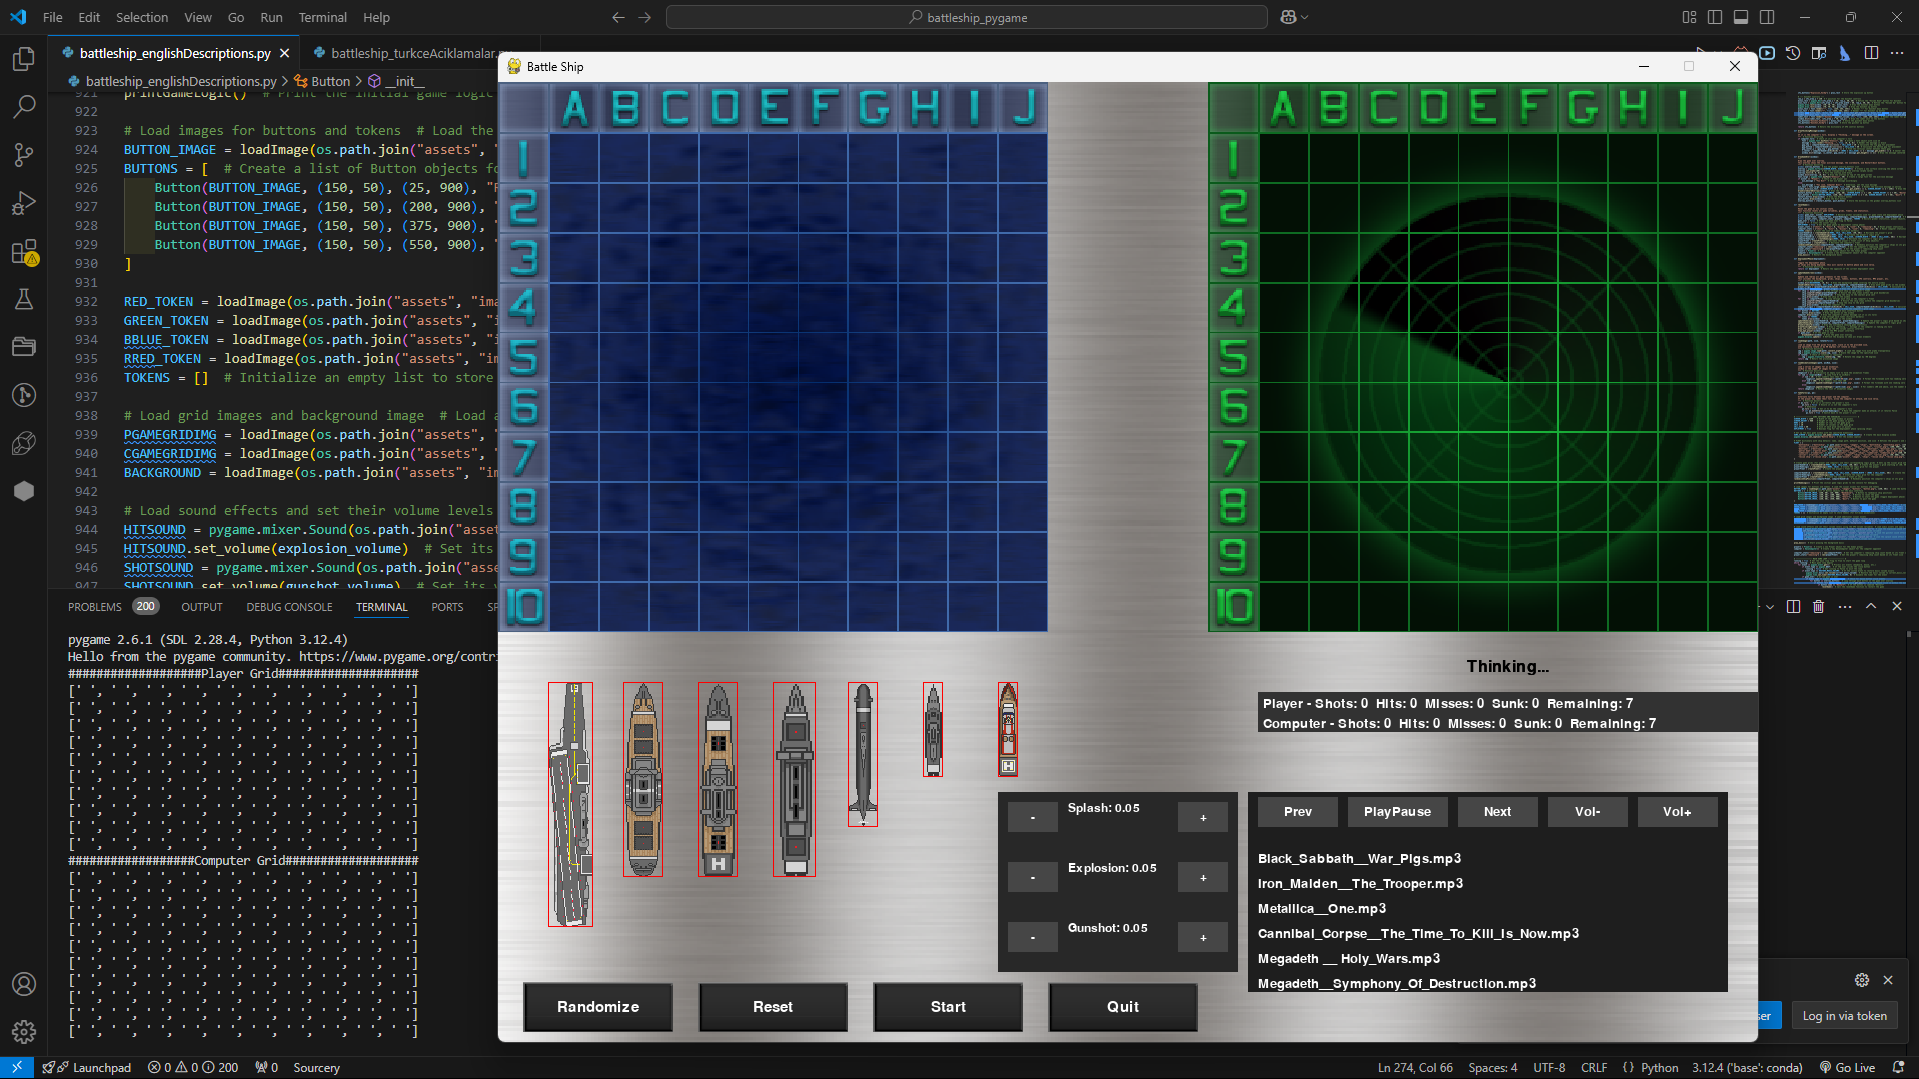

## Introduction, and Project Overview
---

---

In this project, a comprehensive game has been developed using Pygame and based on the classic naval warfare (Battleship) game;
- Deployment of ships (deployment phase),
- Player and computer attack in turn (battle phase),
- Background music (MP3 player interface)
- and separate sound effects (Splash, Explosion, Gunshot) sound controls.

All functions, classes and sections are commented with simple and detailed explanations.

## Game Rules, Strategy, and Roadmap
---



---


### Game Rules
- After placing their ships on the 10x10 grids, the player and the computer take turns shooting at the opponent grid.
- If the ship is hit, the result of the shot is "Hit", if there is no ship, the result is "Miss".
- The game ends when all the opponent ships are sunk.

### Strategy and Game Flow
- **Deployment Phase:** The player places their ships by dragging them with the mouse. The ships are placed on the nearest cell to the grid with the "snap" mechanism.
- **Battle Phase:** The player and the computer take turns shooting at the opponent grid. The computer makes a simple random selection.
- **Interface:**
- There are two grids, a scoreboard and control buttons on the main screen.
- There are MP3 player and SFX sound controls at the bottom.

### Project Roadmap
1. **Required Libraries & Initial Settings:** Importing Pygame, random and os modules, starting Pygame.
2. **Global Variables and Settings:** Game state, statistics, sound settings, music and SFX control variables.

3. **Music and Sound Effect Functions:** Background music playing, pausing, forward/backward switching, temporary music reduction while sound effect is playing.

4. **Game Objects (Classes):**
- **Ship Class:** Ship placement, rotation, grid placement, collision control.

- **Button Class:** In-game buttons creation, mouse interactions and button click actions.

- **Player and EasyComputer Classes:** Player and computer attack logic, turn management.

- **Tokens Class:** Showing the results of shots (hit/miss) with animations.
5. **Auxiliary Functions:** Board creation, logic grid creation, ship placement, scoreboard drawing, MP3 and SFX interfaces.

6. **Game Settings and Resource Loading:** Screen dimensions, ship data (FLEET dictionary), loading image and sound files.

7. **Main Game Loop:** Event management (mouse, keyboard), attack order, sound controls, ship placement and general screen update.

## Import Libraries and Initial Setup
---
---


In [ ]:
import pygame, random, os  # Import modules: pygame for game functions, random for random choices, os for file system paths

# ---------------- INITIAL SETUP ---------------- #
pygame.init()  # Initialize all pygame modules needed for the game

# Get the base directory where this script is located  # Useful for constructing absolute file paths for assets
BASE_PATH = os.path.dirname(os.path.abspath(__file__))  # Get the directory of the current script

* In this cell, the libraries required for the project are imported and the Pygame modules are started. In addition, the directory where the project file is located `(BASE_PATH`) is determined so that correct paths can be created for assets such as images and sound files.

## Global Variables, Stats, Music and SFX Settings
---
---

In [ ]:
# Game state variables to track overall game progress and results

game_over = False              # Boolean flag indicating if the game is finished  # False means game is ongoing
winner = ""                    # Will store the winner as a string ("Player" or "Computer")  # Initially empty
overlay_buttons = []           # List to store button objects that appear in the game over overlay  # Used for Restart/Quit options

# Player and computer statistics (shots, hits, misses, sunk ships, remaining ships)  # These dictionaries store the stats for each side
player_stats = {               # Dictionary for the human player's game statistics
    "shots": 0,               # Number of shots fired by the player  # Initially 0
    "hits": 0,                # Number of successful hits by the player  # Initially 0
    "misses": 0,              # Number of missed shots by the player  # Initially 0
    "sunk": 0,                # Number of enemy ships sunk by the player  # Initially 0
    "remaining": 0            # Number of the player's ships still afloat  # Will be set later
}
computer_stats = {             # Dictionary for the computer's game statistics
    "shots": 0,               # Number of shots fired by the computer  # Initially 0
    "hits": 0,                # Number of successful hits by the computer  # Initially 0
    "misses": 0,              # Number of missed shots by the computer  # Initially 0
    "sunk": 0,                # Number of player's ships sunk by the computer  # Initially 0
    "remaining": 0            # Number of the computer's ships still afloat  # Will be set later
}

# ---------------- BACKGROUND MUSIC SETTINGS ---------------- #
# Define the list of music tracks using absolute paths

bg_music_tracks = [  # List containing file paths for background music tracks
    os.path.join(BASE_PATH, "../assets", "sounds", "Black_Sabbath__War_Pigs.mp3"),  # 1. track path
    os.path.join(BASE_PATH, "../assets", "sounds", "Iron_Maiden__The_Trooper.mp3"),    # 2. track path
    os.path.join(BASE_PATH, "../assets", "sounds", "Metallica__One.mp3"),              # 3. track path
    os.path.join(BASE_PATH, "../assets", "sounds", "Cannibal_Corpse__The_Time_To_Kill_Is_Now.mp3"),  # 4. track path
    os.path.join(BASE_PATH, "../assets", "sounds", "Megadeth __ Holy_Wars.mp3"),  # 5. track path
    os.path.join(BASE_PATH, "../assets", "sounds", "Megadeth__Symphony_Of_Destruction.mp3")  # 6. track path
]

current_track_index = 0        # Index to track which music track is currently playing  # Starts with 0 (the first track)
music_paused = False           # Boolean flag to indicate if the background music is paused  # Initially not paused
normal_music_volume = 0.3      # Default volume level for the music  # Value between 0.0 and 1.0
lowered_music_volume = 0.1     # Volume level to temporarily set when a sound effect plays  # This reduces music during effects
current_music_volume = normal_music_volume  # Current music volume, initially set to the default

# ---------------- SOUND EFFECT VOLUME VARIABLES ---------------- #
# Define individual volume levels for each sound effect

splash_volume = 0.05           # Volume level for the splash sound effect (MISSSOUND)  # Initially set to 0.05
explosion_volume = 0.05        # Volume level for the explosion sound effect (HITSOUND)  # Initially set to 0.05
gunshot_volume = 0.05          # Volume level for the gunshot sound effect (SHOTSOUND)  # Initially set to 0.05

# ---------------- GLOBAL DICTIONARIES FOR BUTTONS ---------------- #
# Declare a dictionary for SFX control buttons so it is accessible in the event loop

sfx_buttons = {}  # Dictionary that will store SFX control button objects  # Keys will be names like "Splash_VolUp"

# ---------------- SPECIAL EVENTS ---------------- #
# Define a custom event to restore music volume after a sound effect is played

RESTORE_MUSIC_VOLUME = pygame.USEREVENT + 1  # Custom event ID for restoring music volume  # Unique identifier for our event


* This cell defines global variables that track the general state of the game, player and computer statistics, background music and sound settings for sound effects, and the global dictionary to be used for the SFX buttons. A special event is also defined to temporarily lower the music volume while the sound effect is playing.

## Music Control Functions
---
---

In [ ]:
def play_music():
    """Load and play the current music track in a loop."""  # Function docstring explaining the purpose
    global music_paused  # Declare that we are using the global variable music_paused
    try:
        pygame.mixer.music.load(bg_music_tracks[current_track_index])  # Load the current music track using its path
        pygame.mixer.music.play(-1)  # Play the music track in an infinite loop (-1 means loop forever)
        pygame.mixer.music.set_volume(current_music_volume)  # Set the music volume to the current music volume
        music_paused = False  # Mark that the music is not paused
    except pygame.error as e:  # If there is an error (e.g., file not found)
        print(f"Error loading music: {e}")  # Print an error message

def pause_music():
    """Pause the background music."""  # Function docstring
    global music_paused  # Use the global music_paused variable
    pygame.mixer.music.pause()  # Pause the music
    music_paused = True  # Set the flag to True

def unpause_music():
    """Unpause the background music."""  # Function docstring
    global music_paused  # Use the global music_paused variable
    pygame.mixer.music.unpause()  # Resume playing the music
    music_paused = False  # Update the flag to False

def next_track():
    """Advance to the next music track and play it."""  # Function docstring
    global current_track_index  # Use the global variable for the track index
    current_track_index = (current_track_index + 1) % len(bg_music_tracks)  # Increment index cyclically
    try:
        pygame.mixer.music.load(bg_music_tracks[current_track_index])  # Load the next track
        pygame.mixer.music.play(-1)  # Play it on loop
        pygame.mixer.music.set_volume(current_music_volume)  # Set the volume
    except pygame.error as e:  # Handle any errors
        print(f"Error loading next track: {e}")  # Print error message

def prev_track():
    """Go back to the previous music track and play it."""  # Function docstring
    global current_track_index  # Use the global track index
    current_track_index = (current_track_index - 1) % len(bg_music_tracks)  # Decrement index cyclically
    try:
        pygame.mixer.music.load(bg_music_tracks[current_track_index])  # Load the previous track
        pygame.mixer.music.play(-1)  # Play it on loop
        pygame.mixer.music.set_volume(current_music_volume)  # Set the volume
    except pygame.error as e:  # Handle errors
        print(f"Error loading previous track: {e}")  # Print error message

def select_track(index):
    """Select a track by its index and play it."""  # Function docstring
    global current_track_index  # Use the global track index
    if 0 <= index < len(bg_music_tracks):  # Check if the index is valid
        current_track_index = index  # Set the current track index
        try:
            pygame.mixer.music.load(bg_music_tracks[current_track_index])  # Load the selected track
            pygame.mixer.music.play(-1)  # Play it on loop
            pygame.mixer.music.set_volume(current_music_volume)  # Set the volume
        except pygame.error as e:  # Handle errors
            print(f"Error selecting track {index}: {e}")  # Print error message

def play_effect(sound):
    """
    Play a sound effect by lowering the music volume temporarily.
    After 500ms, the volume will be restored.
    """  # Function docstring explaining purpose
    pygame.mixer.music.set_volume(lowered_music_volume)  # Lower the music volume during the effect
    sound.play()  # Play the provided sound effect
    pygame.time.set_timer(RESTORE_MUSIC_VOLUME, 500)  # Set a timer to restore the music volume after 500 milliseconds


* This cell contains music control functions such as background music playback, pause, next/previous track switching, and desired track selection. Also, while the sound effect is playing, the background music volume is temporarily lowered and restored to its previous level after 500ms.

## Game Object Classes
---
---


#### Ship Class
---

This class represents the ships in the game.
- **Features:**
- Ship name, starting position, vertical and horizontal images, hitbox (rect) information.
- Ship rotation status, active or not (selected and dragged).
- Which grid cells the ship occupies (occupiedCells) and hit cells (hitCells) are stored.
- **Methods:**
- `draw()`: Draws the ship on the screen.
- `selectShipAndMove()`: Allows selecting and dragging the ship with the mouse.
- `rotateShip()` and `switchImageAndRect()`: Changes the ship's direction.
- `checkForCollisions()`, `snapToGrid()` and `snapToGridEdge()`: Performs ship positioning and collision checks.

In [ ]:
class Ship:
    """Represents a ship in the Battleship game."""  # Class docstring
    def __init__(self, name, img, pos, size):
        self.name = name  # Store the ship name  # e.g., "battleship"
        self.pos = pos  # Store the default starting position as a tuple (x, y)
        self.verticalImage = loadImage(img, size)  # Load the ship's image for vertical orientation using the provided path and size
        self.verticalImageWidth = self.verticalImage.get_width()  # Get the width of the vertical image
        self.verticalImageHeight = self.verticalImage.get_height()  # Get the height of the vertical image
        self.verticalImageRect = self.verticalImage.get_rect()  # Get the rectangle (hitbox) for the vertical image
        self.verticalImageRect.topleft = pos  # Set the rectangle's top-left position to the default position
        self.horizontalImage = pygame.transform.rotate(self.verticalImage, -90)  # Create the horizontal image by rotating the vertical image by -90 degrees
        self.horizontalImageWidth = self.horizontalImage.get_width()  # Get the width of the horizontal image
        self.horizontalImageHeight = self.horizontalImage.get_height()  # Get the height of the horizontal image
        self.horizontalImageRect = self.horizontalImage.get_rect()  # Get the rectangle (hitbox) for the horizontal image
        self.horizontalImageRect.topleft = pos  # Set its top-left position to the default position
        self.image = self.verticalImage  # Set the current image to the vertical image initially
        self.rect = self.verticalImageRect  # Set the current hitbox rectangle to the vertical image's rectangle
        self.rotation = False  # Flag to indicate the ship's orientation; False means vertical, True means horizontal
        self.active = False  # Flag to indicate if the ship is currently selected for movement by the player
        self.occupiedCells = []  # List to store grid cells that the ship occupies once placed
        self.hitCells = []  # List to store grid cells where the ship has been hit
        self.sunk = False  # Flag to indicate if the ship has been sunk

    def draw(self, window):
        """Draw the ship on the game window."""  # Method docstring
        window.blit(self.image, self.rect)  # Draw the current image at the rectangle's position on the window
        pygame.draw.rect(window, (255, 0, 0), self.rect, 1)  # Optionally draw a red border around the ship's rectangle for clarity

    def selectShipAndMove(self):
        """
        Allow the player to select and move the ship with the mouse.
        The ship follows the mouse until it is placed (with a left-click) or rotated (with a right-click).
        """  # Method docstring
        while self.active:  # Loop while the ship is active (being moved)
            self.rect.center = pygame.mouse.get_pos()  # Update the ship's center to the mouse pointer's current position
            updateGameScreen(GAME_SCREEN)  # Redraw the game screen with the updated ship position
            for event in pygame.event.get():  # Process events while moving the ship
                if event.type == pygame.MOUSEBUTTONDOWN:  # Check for a mouse click event
                    if not self.checkForCollisions(playerFleet):  # If the ship does not collide with others
                        if event.button == 1:  # If the left mouse button is clicked
                            self.horizontalImageRect.center = self.verticalImageRect.center = self.rect.center  # Align both orientations' centers
                            self.active = False  # Stop moving the ship (it is placed)
                    if event.button == 3:  # If the right mouse button is clicked
                        self.rotateShip()  # Rotate the ship

    def rotateShip(self, doRotation=False):
        """
        Rotate the ship between vertical and horizontal orientations.
        If doRotation is True, force the rotation even if the ship is not active.
        """  # Method docstring
        if self.active or doRotation:  # Only rotate if the ship is being moved or forced to rotate
            self.rotation = not self.rotation  # Toggle the rotation flag
            self.switchImageAndRect()  # Update the current image and rectangle based on the new orientation

    def switchImageAndRect(self):
        """
        Switch the current image and its rectangle based on the rotation state.
        This maintains the ship's center position.
        """  # Method docstring
        if self.rotation:  # If the ship is rotated (horizontal)
            self.image = self.horizontalImage  # Set the current image to the horizontal version
            self.rect = self.horizontalImageRect  # Set the hitbox to the horizontal rectangle
        else:  # If the ship is not rotated (vertical)
            self.image = self.verticalImage  # Set the current image to the vertical version
            self.rect = self.verticalImageRect  # Set the hitbox to the vertical rectangle
        self.horizontalImageRect.center = self.verticalImageRect.center = self.rect.center  # Ensure both rectangles share the same center

    def checkForCollisions(self, shipList):
        """
        Check if this ship collides with any other ship in the provided list.
        Returns True if a collision is detected.
        """  # Method docstring
        sList = shipList.copy()  # Create a copy of the ship list to avoid modifying the original
        sList.remove(self)  # Remove this ship from the list since we don't compare it with itself
        for item in sList:  # Loop through the remaining ships
            if self.rect.colliderect(item.rect):  # Check if this ship's rectangle collides with another ship's rectangle
                return True  # Collision found, return True
        return False  # No collisions found, return False

    def returnToDefaultPosition(self):
        """Return the ship to its original default position."""  # Method docstring
        if self.rotation:  # If the ship is rotated
            self.rotateShip(True)  # Rotate it back to vertical (forcing the rotation)
        self.rect.topleft = self.pos  # Reset the rectangle's top-left position to the default position
        self.horizontalImageRect.center = self.verticalImageRect.center = self.rect.center  # Realign the centers

    def snapToGrid(self, gridCoords):
        """
        Snap the ship's position to the nearest grid cell.
        Also update the list of grid cells that the ship occupies.
        """  # Method docstring
        for i, row in enumerate(gridCoords):  # Loop through each row of the grid
            for j, cell in enumerate(row):  # Loop through each cell in the row
                # Check if the ship's left and top fall within the current cell's boundaries
                if (self.rect.left >= cell[0] and self.rect.left < cell[0] + CELL_SIZE and
                    self.rect.top >= cell[1] and self.rect.top < cell[1] + CELL_SIZE):
                    if not self.rotation:  # If the ship is vertical
                        # Center the ship horizontally within the cell
                        self.rect.topleft = (cell[0] + (CELL_SIZE - self.image.get_width()) // 2, cell[1])
                        cell_count = max(1, round(self.verticalImage.get_height() / CELL_SIZE))  # Determine how many cells the ship occupies vertically
                        self.occupiedCells = [(i + k, j) for k in range(cell_count) if i + k < len(gridCoords)]  # Record the grid cells occupied
                    else:  # If the ship is horizontal
                        self.rect.topleft = (cell[0], cell[1] + (CELL_SIZE - self.image.get_height()) // 2)  # Center vertically
                        cell_count = max(1, round(self.horizontalImage.get_width() / CELL_SIZE))  # Determine how many cells the ship occupies horizontally
                        self.occupiedCells = [(i, j + k) for k in range(cell_count) if j + k < len(row)]  # Record the grid cells occupied
                    self.horizontalImageRect.center = self.verticalImageRect.center = self.rect.center  # Realign the centers of both images
                    return  # Exit once the ship has been snapped

    def snapToGridEdge(self, gridCoords):
        """
        Ensure the ship remains within the grid boundaries.
        If the ship is outside, return it to its default position.
        """  # Method docstring
        if self.rect.topleft != self.pos:  # Only check if the ship has moved from its default position
            if (self.rect.left > gridCoords[0][-1][0] + CELL_SIZE or
                self.rect.right < gridCoords[0][0][0] or
                self.rect.top > gridCoords[-1][0][1] + CELL_SIZE or
                self.rect.bottom < gridCoords[0][0][1]):
                self.returnToDefaultPosition()  # Return the ship to its default position if it's completely outside the grid
            elif self.rect.right > gridCoords[0][-1][0] + CELL_SIZE:  # If the ship goes off the right edge
                self.rect.right = gridCoords[0][-1][0] + CELL_SIZE  # Align it with the right edge
            elif self.rect.left < gridCoords[0][0][0]:  # If the ship goes off the left edge
                self.rect.left = gridCoords[0][0][0]  # Align it with the left edge
            elif self.rect.top < gridCoords[0][0][1]:  # If the ship goes above the grid
                self.rect.top = gridCoords[0][0][1]  # Align it with the top
            elif self.rect.bottom > gridCoords[-1][0][1] + CELL_SIZE:  # If the ship goes below the grid
                self.rect.bottom = gridCoords[-1][0][1] + CELL_SIZE  # Align it with the bottom
            self.verticalImageRect.center = self.horizontalImageRect.center = self.rect.center  # Realign the centers
            self.snapToGrid(gridCoords)  # Snap the ship to the nearest grid cell again

In this code block, Ship class is defined to control the behavior of ships in the game.

- `selectShipAndMove`: Allows the user to drag and place the ship with the mouse.

- `rotateShip` & `switchImageAndRect`: Changes the orientation of the ship (vertical/horizontal).

- `snapToGrid` & `snapToGridEdge`: Snaps the ship to the grid and prevents it from going off the grid.
Each method is commented with a docstring that contains a short explanation of its function.

#### Button Class

---

This class defines interactive buttons in the game interface.
- **Properties:**
- Button image, hover effect and text to be written on it.
- **Methods:**
    - `draw()`: Draws the image and text of the button.
    - `actionOnPress()`: Determines which action the button will perform on click.

In [ ]:

class Button:
    """Represents an interactive button in the game interface."""  # Class docstring
    def __init__(self, image, size, pos, msg):
        self.name = msg  # Store the button name which is also used as the label
        self.image = image  # Store the base image for the button
        self.imageLarger = pygame.transform.scale(self.image, (size[0] + 10, size[1] + 10))  # Create a slightly larger image for hover effect
        self.rect = self.image.get_rect()  # Get the button's rectangle (position and size)
        self.rect.topleft = pos  # Set the rectangle's top-left position to the given position
        self.active = False  # Set active state (not used in this code but can be used for toggling)
        self.msg = self.addText(msg)  # Render the button text using the addText method
        self.msgRect = self.msg.get_rect(center=self.rect.center)  # Center the text within the button

    def addText(self, msg):
        """Render the button text using a simple font."""  # Method docstring
        font = pygame.font.SysFont("Stencil", 22)  # Choose the "Stencil" font with size 22
        message = font.render(msg, True, (255, 255, 255))  # Render the text in white color
        return message  # Return the rendered text surface

    def draw(self, window):
        """Draw the button (image and text) on the window."""  # Method docstring
        self.focusOnButton(window)  # Draw the button image (with hover effect if applicable)
        window.blit(self.msg, self.msgRect)  # Draw the text on top of the button

    def focusOnButton(self, window):
        """
        If the mouse pointer is over the button, draw the larger version.
        Otherwise, draw the normal image.
        """  # Method docstring
        if self.rect.collidepoint(pygame.mouse.get_pos()):  # Check if mouse is over the button
            window.blit(self.imageLarger, (self.rect.x - 5, self.rect.y - 5))  # Draw the larger image for emphasis
        else:
            window.blit(self.image, self.rect)  # Otherwise, draw the regular image

    def actionOnPress(self):
        """
        Define the action that occurs when the button is pressed.
        Based on the button's name, perform different tasks.
        """  # Method docstring
        global DEPLOYMENT, game_over  # Use global variables for deployment phase and game_over flag
        if self.name == "Randomize":  # If the button's name is "Randomize"
            self.randomizeShipPositions(playerFleet, playerGameGrid)  # Randomize positions for the player's ships
            self.randomizeShipPositions(computerFleet, computerGameGrid)  # Randomize positions for the computer's ships
        elif self.name == "Reset":  # If the button's name is "Reset"
            resetGame()  # Call the resetGame function to restart the game
        elif self.name == "Start":  # If the button's name is "Start"
            if game_over:  # If the game is over
                resetGame()  # Reset the game
            else:
                DEPLOYMENT = deploymentPhase(DEPLOYMENT)  # Toggle the deployment phase
                print("Deployment:", DEPLOYMENT)  # Print the new deployment state to the console
        elif self.name == "Quit":  # If the button's name is "Quit"
            pass  # The quit action is handled in the main loop

    def resetShip(self, shipList):
        """Reset positions of all ships in the provided list."""  # Method docstring
        if DEPLOYMENT:  # Only perform if in deployment phase
            for ship in shipList:  # Loop through each ship
                ship.returnToDefaultPosition()  # Return the ship to its default starting position

    def randomizeShipPositions(self, shipList, gameGrid):
        """Randomly place the ships on the given grid."""  # Method docstring
        if DEPLOYMENT:  # Only perform if in deployment phase
            randomizeShipPositions(shipList, gameGrid)  # Call the randomizeShipPositions function

In this section, the Button class is used to create in-game control buttons.

In the case of a click (actionOnPress), the ship locations are randomly distributed, the game is reset, the deployment phase is started or the exit is performed according to the name of the button.

#### Player Class
---

This class contains the logic for the real player to attack.
- **Methods:**
- `makeAttack()`: Makes the player shoot at the opponent's grid by clicking with the mouse, checks the hit/miss status and updates the statistics.

In [ ]:
class Player:
    """Represents the human player."""  # Class docstring
    def __init__(self):
        self.turn = True  # Set turn to True to indicate that the human player starts first

    def makeAttack(self, grid, logicGrid):
        """
        Handle the player's attack when clicking on the enemy grid.
        Update game logic and statistics based on whether the shot is a hit or a miss.
        """  # Method docstring
        global player_stats, computer_stats, game_over, winner  # Use global variables for stats and game state
        posX, posY = pygame.mouse.get_pos()  # Get the current mouse position (x, y)
        # Check if the mouse click is within the boundaries of the enemy grid
        if (posX >= grid[0][0][0] and posX <= grid[0][-1][0] + CELL_SIZE and
            posY >= grid[0][0][1] and posY <= grid[-1][0][1] + CELL_SIZE):
            for i, row in enumerate(grid):  # Loop through each row in the grid
                for j, cell in enumerate(row):  # Loop through each cell in the row
                    # Check if the click is within the current cell boundaries
                    if (posX >= cell[0] and posX < cell[0] + CELL_SIZE and
                        posY >= cell[1] and posY < cell[1] + CELL_SIZE):
                        player_stats["shots"] += 1  # Increment the player's shot count
                        SHOTSOUND.play()  # Play the gunshot sound effect
                        if logicGrid[i][j] != " ":  # If the cell is marked (indicating a ship is there)
                            if logicGrid[i][j] == "O":  # If the cell contains a ship
                                print("Hit")  # Print "Hit" to the console
                                HITSOUND.play()  # Play the explosion sound effect
                                TOKENS.append(Tokens(GREEN_TOKEN, grid[i][j], "Hit", None, None))  # Add a token marking the hit
                                logicGrid[i][j] = "H"  # Update the logic grid to mark the cell as hit
                                for ship in computerFleet:  # Loop through each computer ship
                                    if (i, j) in ship.occupiedCells and (i, j) not in ship.hitCells:  # Check if the hit cell is part of the ship and not already hit
                                        ship.hitCells.append((i, j))  # Mark this cell as hit on the ship
                                        player_stats["hits"] += 1  # Increment the player's hit count
                                        if len(ship.hitCells) == len(ship.occupiedCells) and not ship.sunk:  # If all cells of the ship are hit and it isn't already sunk
                                            ship.sunk = True  # Mark the ship as sunk
                                            player_stats["sunk"] += 1  # Increment the sunk count for the player
                                            computer_stats["remaining"] -= 1  # Decrement the number of computer ships remaining
                                            print(f"Computer ship sunk: {ship.name}")  # Print a message with the ship's name
                                self.turn = False  # End the player's turn after a hit
                        else:  # If the cell is empty (no ship)
                            print("Miss")  # Print "Miss" to the console
                            MISSSOUND.play()  # Play the splash sound effect
                            TOKENS.append(Tokens(RED_TOKEN, grid[i][j], "Miss", None, None))  # Add a token marking the miss
                            logicGrid[i][j] = "M"  # Update the logic grid to mark the cell as a miss
                            player_stats["misses"] += 1  # Increment the player's miss count
                            self.turn = False  # End the player's turn after a miss
        if computer_stats["remaining"] <= 0:  # Check if the computer has no remaining ships
            game_over = True  # Set game_over to True
            winner = "Player"  # Declare the player as the winner

* This class detects which cell the player clicks on when attacking, plays the corresponding sound effects, and updates the logic grid and statistics based on hit/miss status.

#### EasyComputer Class
----

This class contains the attack logic for a simple computer opponent and the message "Thinking...".
- **Methods:**
- `makeAttack()`: Makes the computer choose a random cell after a 2 second wait and launches an attack.
- `draw()`: If it is the computer's turn, it displays the message "Thinking..." on the screen.

In [ ]:

class EasyComputer:
    """Represents a simple computer opponent."""  # Class docstring
    def __init__(self):
        self.turn = True  # Set turn to True when it's the computer's turn
        self.status = self.computerStatus("Thinking...")  # Initialize a status message ("Thinking...")
        self.name = "Easy Computer"  # Set the computer's name

    def computerStatus(self, msg):
        """
        Render and return a status message for the computer.
        This message (e.g., "Thinking...") is displayed on the screen.
        """  # Method docstring
        font = pygame.font.SysFont("Stencil", 22)  # Choose the "Stencil" font with size 22
        message = font.render(msg, True, (0, 0, 0))  # Render the message in black
        return message  # Return the rendered text surface

    def makeAttack(self, gameLogic):
        """
        The computer makes an attack on the player's grid.
        It waits 2 seconds (to simulate thinking) and then randomly selects a valid cell.
        Game logic and statistics are updated based on the result.
        """  # Method docstring
        global computer_stats, player_stats, game_over, winner  # Use global variables for stats and game state
        start_time = pygame.time.get_ticks()  # Record the current time in milliseconds
        while pygame.time.get_ticks() - start_time < 2000:  # Wait for 2 seconds (2000 milliseconds)
            updateGameScreen(GAME_SCREEN)  # Keep updating the game screen during the wait (to show "Thinking...")
        validChoice = False  # Initialize a flag for valid cell selection
        while not validChoice:  # Loop until a valid cell is selected
            rowX = random.randint(0, 9)  # Choose a random row index (0 to 9)
            colX = random.randint(0, 9)  # Choose a random column index (0 to 9)
            if gameLogic[rowX][colX] == " " or gameLogic[rowX][colX] == "O":  # Check if the cell is available for attack
                validChoice = True  # Mark the choice as valid
        computer_stats["shots"] += 1  # Increment the computer's shot count
        SHOTSOUND.play()  # Play the gunshot sound effect
        if gameLogic[rowX][colX] == "O":  # If the chosen cell contains a ship
            print("Hit Player's Ship")  # Print a hit message to the console
            HITSOUND.play()  # Play the explosion sound effect
            TOKENS.append(Tokens(RED_TOKEN, playerGameGrid[rowX][colX], "Hit", None, None))  # Add a token marking the hit
            gameLogic[rowX][colX] = "H"  # Update the logic grid to mark a hit
            for ship in playerFleet:  # Loop through each player ship
                if (rowX, colX) in ship.occupiedCells and (rowX, colX) not in ship.hitCells:  # Check if the cell belongs to the ship and is not already hit
                    ship.hitCells.append((rowX, colX))  # Mark the cell as hit for the ship
                    computer_stats["hits"] += 1  # Increment the computer's hit count
                    if len(ship.hitCells) == len(ship.occupiedCells) and not ship.sunk:  # If the entire ship is hit and it is not marked as sunk
                        ship.sunk = True  # Mark the ship as sunk
                        computer_stats["sunk"] += 1  # Increment the sunk count for the computer
                        player_stats["remaining"] -= 1  # Decrease the number of player's ships remaining
                        print(f"Player ship sunk: {ship.name}")  # Print which ship was sunk
            self.turn = False  # End the computer's turn after a hit
        else:  # If the chosen cell does not contain a ship
            gameLogic[rowX][colX] = "M"  # Mark the cell as a miss in the logic grid
            print("Missed")  # Print "Missed" to the console
            MISSSOUND.play()  # Play the splash sound effect
            TOKENS.append(Tokens(GREEN_TOKEN, playerGameGrid[rowX][colX], "Miss", None, None))  # Add a token marking the miss
            computer_stats["misses"] += 1  # Increment the computer's miss count
            self.turn = False  # End the computer's turn after a miss
        if player_stats["remaining"] <= 0:  # Check if the player has no ships remaining
            game_over = True  # Set the game over flag to True
            winner = "Computer"  # Declare the computer as the winner
        return self.turn  # Return the turn status

    def draw(self, window):
        """If it is the computer's turn, display a "Thinking..." message on the screen."""  # Method docstring
        if self.turn:  # Check if it is currently the computer's turn
            font = pygame.font.SysFont("Stencil", 24)  # Choose the "Stencil" font with size 24
            message = font.render("Thinking...", True, (0, 0, 0))  # Render the text "Thinking..." in black
            gap_top = computerGameGrid[-1][-1][1] + CELL_SIZE + 10  # Calculate the top gap for the message placement
            gap_bottom = computerGameGrid[-1][-1][1] + CELL_SIZE + 60  # Calculate the bottom gap for message placement
            gap_center_y = (gap_top + gap_bottom) // 2  # Find the vertical center between the two gaps
            x_center = computerGameGrid[0][0][0] + (ROWS * CELL_SIZE) // 2 - message.get_width() // 2  # Center the message horizontally in the computer grid area
            window.blit(message, (x_center, gap_center_y - message.get_height() // 2))  # Draw the "Thinking..." message


* This class contains a simple attack logic for the computer opponent. After a 2-second "thinking" period, the computer randomly selects a cell, updates statistics according to the attack result, and displays the "Thinking..." message on the screen.

#### Tokens Class
---

This class is used to display Hit/Miss animations and visual cues (tokens) on the screen.
- **Methods:**
- `animateExplosion()` and `animateFire()`: Displays explosion and fire animations in sequence.
- `draw()`: Draws the token animation on the screen.

In [ ]:

class Tokens:
    """Represents animated tokens used to mark hits or misses on the grid."""  # Class docstring
    def __init__(self, image, pos, action, imageList=None, explosionList=None, soundFile=None):
        self.image = image  # Store the base image for the token (e.g., red or green marker)
        self.rect = self.image.get_rect()  # Get the rectangle (position and size) of the token image
        self.pos = pos  # Store the position where the token should be drawn
        self.rect.topleft = self.pos  # Set the rectangle's top-left position to the token's position
        self.imageList = imageList  # Optional list of images for animating the token (if available)
        self.explosionList = explosionList  # Optional list of explosion images for animation
        self.action = action  # Store the action type (e.g., "Hit" or "Miss")
        self.soundFile = soundFile  # Optionally store a sound file associated with the token
        self.timer = pygame.time.get_ticks()  # Record the current time for controlling animation timing
        self.explosionIndex = 0  # Index for the current frame of the explosion animation
        self.explosion = False  # Flag to indicate whether to play the explosion animation
        self.imageIndex = 0  # Index for the current frame of a fire (or other) animation

    def animateExplosion(self):
        """Animate the explosion effect. If finished, animate the fire effect instead."""  # Method docstring
        self.explosionIndex += 1  # Increment the explosion frame index
        if self.explosionList and self.explosionIndex < len(self.explosionList):  # If explosion images are provided and not finished
            return self.explosionList[self.explosionIndex]  # Return the next explosion frame
        else:
            return self.animateFire()  # Otherwise, fall back to the fire animation

    def animateFire(self):
        """Animate the fire effect for the token."""  # Method docstring
        if pygame.time.get_ticks() - self.timer >= 100:  # Check if 100 milliseconds have passed since the last frame update
            self.timer = pygame.time.get_ticks()  # Reset the timer to the current time
            self.imageIndex = 1  # Update the image index to the next frame (for simplicity, this toggles to 1)
        if self.imageList and self.imageIndex < len(self.imageList):  # If an animation image list is available and index is within range
            return self.imageList[self.imageIndex]  # Return the corresponding frame
        else:
            self.imageIndex = 0  # Otherwise, reset the index
            return self.imageList[self.imageIndex] if self.imageList else self.image  # Return the first frame or the base image

    def draw(self, window):
        """Draw the token on the screen with its animation."""  # Method docstring
        if not self.imageList:  # If no animation images are provided
            window.blit(self.image, self.rect)  # Simply draw the base image
        else:
            self.image = self.animateExplosion()  # Update the image using the explosion animation (or fire animation)
            self.rect = self.image.get_rect(topleft=self.pos)  # Update the rectangle based on the new image, keeping the same position
            self.rect.y = self.pos[1] - 10  # Adjust the y position slightly for visual effect
            window.blit(self.image, self.rect)  # Draw the animated image


* This class controls the visual cues (hit/miss) and animations that occur as a result of a shot. Explosion and fire animations are applied for transitions during the animation.

## HELPER FUNCTIONS
---
---

This section includes auxiliary functions such as creating the game's board structure, logic grid, creating a ship fleet, random ship placement, drawing scoreboards and other visual elements.

Functions:
- `createGameGrid()`: Creates the coordinates of the grid to be drawn on the screen.
- `createGameLogic()`: Creates the logic grid; each cell is initially set to empty (" ").
- `showGridOnScreen()`: Draws the player and computer grids on the screen.
- `printGameLogic()`: Prints the logic grid to the console for debugging purposes.
- `createFleet()`: Creates ship objects according to the FLEET dictionary.
- `sortFleet()`: Moves the selected ship to the end of the list in terms of drawing order.
- `randomizeShipPositions()`: Allows ships to be placed on the grid randomly and without overlapping.
- `updateGameLogic()`: Updates the logic grid based on the ships' positions on the grid.
- `drawScoreboard()` and `drawScoreboardOverlay()`: Draws the scoreboard to the screen.
- `draw_mp3_player()` and `draw_sfx_controls()`: Creates the MP3 player and SFX control interfaces.
- `drawThinkingMessage()`: Draws the computer's "Thinking..." message to the screen.
- `drawGameOver()`: Creates the game over overlay when the game is over.
- `resetGame()`: Resets the game from the beginning.
- `deploymentPhase()`: Toggle the deployment phase.
- `updateGameScreen()`: Updates the entire screen.
- `loadImage()` and `loadAnimationImages()`: Loads and scales image files.
- `takeTurns()`: Allows the player and the computer to switch turns.

In [ ]:
def createGameGrid(rows, cols, cellsize, pos):
    """
    Create a 2D grid of coordinates for the game board.
    Each cell is represented by its top-left coordinate.
    """  # Function docstring
    start_X = pos[0]  # Starting x-coordinate for the grid
    start_Y = pos[1]  # Starting y-coordinate for the grid
    coordGrid = []  # Initialize an empty list to hold the grid coordinates
    for row in range(rows):  # Loop over the number of rows
        row_coords = []  # Create a list for the current row's coordinates
        for col in range(cols):  # Loop over the number of columns
            row_coords.append((start_X, start_Y))  # Append the coordinate tuple for the current cell
            start_X += cellsize  # Move to the next cell in x-direction by the cell size
        coordGrid.append(row_coords)  # Append the current row to the grid
        start_X = pos[0]  # Reset x-coordinate for the new row
        start_Y += cellsize  # Move to the next row in the y-direction by the cell size
    return coordGrid  # Return the full grid of coordinates

def createGameLogic(rows, cols):
    """
    Create a 2D logic grid representing the game state.
    Each cell is initialized with a space " " to indicate no ship.
    """  # Function docstring
    gameLogic = []  # Initialize an empty list for the logic grid
    for row in range(rows):  # Loop over the number of rows
        row_logic = []  # Initialize a list for the current row's logic values
        for col in range(cols):  # Loop over the number of columns
            row_logic.append(" ")  # Append a space for each cell, meaning it's empty
        gameLogic.append(row_logic)  # Append the row to the logic grid
    return gameLogic  # Return the full logic grid

def showGridOnScreen(window, cellsize, playerGrid, computerGrid):
    """
    Draw both the player's and computer's grids on the game window.
    Each cell is outlined in white.
    """  # Function docstring
    for grid in [playerGrid, computerGrid]:  # Loop over both grids
        for row in grid:  # Loop through each row in the grid
            for cell in row:  # Loop through each cell in the row
                pygame.draw.rect(window, (255, 255, 255), (cell[0], cell[1], cellsize, cellsize), 1)  # Draw a rectangle outline for the cell

def printGameLogic():
    """
    Print the logic grid to the console for debugging.
    """  # Function docstring
    print("Player Grid".center(50, "#"))  # Print a header for the player grid, centered with '#' characters
    for row in playerGameLogic:  # Loop through each row in the player's logic grid
        print(row)  # Print the row
    print("Computer Grid".center(50, "#"))  # Print a header for the computer grid
    for row in computerGameLogic:  # Loop through each row in the computer's logic grid
        print(row)  # Print the row

def createFleet():
    """
    Create a list of Ship objects based on the FLEET dictionary.
    """  # Function docstring
    fleet = []  # Initialize an empty list for the fleet
    for name in FLEET.keys():  # Loop over each key (ship name) in the FLEET dictionary
        fleet.append(Ship(name, FLEET[name][1], FLEET[name][2], FLEET[name][3]))  # Create a Ship object using the details from the dictionary and append it to the fleet list
    return fleet  # Return the list of Ship objects

def sortFleet(ship, shipList):
    """
    Reorder the fleet list by moving the selected ship to the end.
    This can be used to change drawing order.
    """  # Function docstring
    shipList.remove(ship)  # Remove the specified ship from its current position in the list
    shipList.append(ship)  # Append it to the end of the list

def randomizeShipPositions(shipList, gameGrid):
    """
    Randomly place ships on the grid ensuring that they do not overlap.
    """  # Function docstring
    placedShips = []  # Initialize a list to keep track of ships that have been placed
    for ship in shipList:  # Loop through each ship in the fleet
        validPosition = False  # Flag to check if the current ship's position is valid (non-overlapping)
        while not validPosition:  # Continue until a valid position is found
            ship.returnToDefaultPosition()  # Reset the ship to its default starting position
            rotateShip = random.choice([True, False])  # Randomly decide whether to rotate the ship
            if rotateShip:  # If rotation is chosen
                yAxis = random.randint(0, 9)  # Randomly choose a row index
                xAxis = random.randint(0, 9 - (ship.horizontalImage.get_width() // CELL_SIZE))  # Randomly choose a column index ensuring it fits horizontally
                ship.rotateShip(True)  # Force the ship to rotate to horizontal
                ship.rect.topleft = gameGrid[yAxis][xAxis]  # Place the ship at the chosen grid cell
            else:  # If no rotation
                yAxis = random.randint(0, 9 - (ship.verticalImage.get_height() // CELL_SIZE))  # Randomly choose a row index ensuring it fits vertically
                xAxis = random.randint(0, 9)  # Randomly choose a column index
                ship.rect.topleft = gameGrid[yAxis][xAxis]  # Place the ship at the chosen grid cell
            validPosition = True  # Assume the position is valid
            for item in placedShips:  # Loop through already placed ships
                if ship.rect.colliderect(item.rect):  # If the current ship's rectangle collides with another
                    validPosition = False  # Mark the position as invalid
                    break  # Break out of the loop to choose a new position
        ship.snapToGrid(gameGrid)  # Snap the ship to the grid properly
        placedShips.append(ship)  # Add the ship to the list of placed ships

def updateGameLogic(coordGrid, shipList, gameLogic):
    """
    Update the logic grid based on the positions of ships.
    Cells occupied by a ship are marked with an "O".
    """  # Function docstring
    for i, row in enumerate(coordGrid):  # Loop over each row index and row in the coordinate grid
        for j, cell in enumerate(row):  # Loop over each column index and cell
            if gameLogic[i][j] in ["H", "M"]:  # If the cell is already marked as hit ("H") or miss ("M")
                continue  # Skip updating that cell
            else:
                gameLogic[i][j] = " "  # Otherwise, reset the cell to an empty space
            for ship in shipList:  # Loop through each ship in the fleet
                if pygame.Rect(cell[0], cell[1], CELL_SIZE, CELL_SIZE).colliderect(ship.rect):  # If the cell rectangle collides with the ship's rectangle
                    gameLogic[i][j] = "O"  # Mark the cell with an "O" to indicate the presence of a ship

def drawScoreboard(window):
    """
    Draw the scoreboard below the computer grid.
    It displays shots, hits, misses, sunk ships, and remaining ships for both players.
    """  # Function docstring
    font = pygame.font.SysFont("Stencil", 20)  # Create a font object using the "Stencil" font with size 20
    player_text = (f"Player - Shots: {player_stats['shots']}  Hits: {player_stats['hits']}  "  # Build the player stats string
                   f"Misses: {player_stats['misses']}  Sunk: {player_stats['sunk']}  "
                   f"Remaining: {player_stats['remaining']}")
    computer_text = (f"Computer - Shots: {computer_stats['shots']}  Hits: {computer_stats['hits']}  "  # Build the computer stats string
                     f"Misses: {computer_stats['misses']}  Sunk: {computer_stats['sunk']}  "
                     f"Remaining: {computer_stats['remaining']}")
    x_pos = computerGameGrid[0][0][0]  # X position for the scoreboard, aligned with the computer grid
    y_pos = computerGameGrid[-1][-1][1] + CELL_SIZE + 60  # Y position below the computer grid with some padding
    scoreboard_width = ROWS * CELL_SIZE  # Width of the scoreboard, covering the grid width
    pygame.draw.rect(window, (50, 50, 50), (x_pos, y_pos, scoreboard_width, 40))  # Draw a background rectangle for the scoreboard
    text_surf_player = font.render(player_text, True, (255, 255, 255))  # Render the player stats text in white
    text_surf_computer = font.render(computer_text, True, (255, 255, 255))  # Render the computer stats text in white
    window.blit(text_surf_player, (x_pos + 5, y_pos + 5))  # Draw the player text slightly inset from the top-left of the scoreboard
    window.blit(text_surf_computer, (x_pos + 5, y_pos + 25))  # Draw the computer text below the player text

def drawScoreboardOverlay(window):
    """
    Draw the scoreboard on the game over overlay.
    This shows the final scores of both players.
    """  # Function docstring
    font = pygame.font.SysFont("Stencil", 20)  # Create a font object for the overlay scoreboard
    player_text = (f"Player - Shots: {player_stats['shots']}  Hits: {player_stats['hits']}  "  # Build the player stats string
                   f"Misses: {player_stats['misses']}  Sunk: {player_stats['sunk']}  "
                   f"Remaining: {player_stats['remaining']}")
    computer_text = (f"Computer - Shots: {computer_stats['shots']}  Hits: {computer_stats['hits']}  "  # Build the computer stats string
                     f"Misses: {computer_stats['misses']}  Sunk: {computer_stats['sunk']}  "
                     f"Remaining: {computer_stats['remaining']}")
    scoreboard_width = SCREEN_WIDTH - 100  # Set the width of the overlay scoreboard
    x_pos = 50  # X position with a margin
    y_pos = SCREEN_HEIGHT // 2 - 50  # Y position centered vertically with an offset
    pygame.draw.rect(window, (50, 50, 50), (x_pos, y_pos, scoreboard_width, 60))  # Draw the background rectangle for the overlay scoreboard
    text_surf_player = pygame.font.SysFont("Stencil", 20).render(player_text, True, (255, 255, 255))  # Render the player stats text
    text_surf_computer = pygame.font.SysFont("Stencil", 20).render(computer_text, True, (255, 255, 255))  # Render the computer stats text
    window.blit(text_surf_player, (x_pos + 5, y_pos + 5))  # Blit (draw) the player text onto the overlay
    window.blit(text_surf_computer, (x_pos + 5, y_pos + 35))  # Blit the computer text onto the overlay

def draw_mp3_player(window):
    """
    Draw the MP3 player interface.
    This includes control buttons and track names.
    Updated coordinates prevent overlapping with game elements.
    """  # Function docstring
    global mp3_button_rects, mp3_song_rects  # Use global dictionaries to store button and song rectangle objects
    mp3_area = pygame.Rect(750, SCREEN_HEIGHT - 250, SCREEN_WIDTH - 780, 200)  # Define the area for the MP3 player interface
    pygame.draw.rect(window, (30, 30, 30), mp3_area)  # Draw the background rectangle for the MP3 player
    font = pygame.font.SysFont("Stencil", 20)  # Create a font object for the MP3 player text
    mp3_button_rects = {  # Define the control buttons for the MP3 player with their positions and sizes
        "Prev": pygame.Rect(760, SCREEN_HEIGHT - 245, 80, 30),  # "Prev" button rectangle
        "PlayPause": pygame.Rect(850, SCREEN_HEIGHT - 245, 100, 30),  # "PlayPause" button rectangle
        "Next": pygame.Rect(960, SCREEN_HEIGHT - 245, 80, 30),  # "Next" button rectangle
        "Vol-": pygame.Rect(1050, SCREEN_HEIGHT - 245, 80, 30),  # "Volume Down" button rectangle for music
        "Vol+": pygame.Rect(1140, SCREEN_HEIGHT - 245, 80, 30)  # "Volume Up" button rectangle for music
    }
    for key, rect in mp3_button_rects.items():  # Loop through each MP3 control button
        pygame.draw.rect(window, (70, 70, 70), rect)  # Draw the button background rectangle in a dark gray color
        text = font.render(key, True, (255, 255, 255))  # Render the button's label text in white
        window.blit(text, (rect.x + (rect.width - text.get_width()) // 2,
                           rect.y + (rect.height - text.get_height()) // 2))  # Draw the text centered on the button
    mp3_song_rects = {}  # Initialize an empty dictionary to store track name rectangles
    start_y = SCREEN_HEIGHT - 190  # Define the starting y-coordinate for the track names
    for i, track in enumerate(bg_music_tracks):  # Loop through each music track in the list
        track_name = os.path.basename(track)  # Get the file name from the full path
        song_text = font.render(track_name, True, (255, 255, 255))  # Render the track name in white
        song_rect = pygame.Rect(760, start_y + i * 25, 300, 20)  # Create a rectangle for each track name
        window.blit(song_text, (song_rect.x, song_rect.y))  # Draw the track name on the screen
        mp3_song_rects[i] = song_rect  # Save the rectangle in the dictionary with the track index as key
    return mp3_button_rects, mp3_song_rects  # Return the dictionaries for further use in event handling

def draw_sfx_controls(window):
    """
    Draw the sound effect (SFX) volume controls.
    This section is placed to the left of the MP3 player.
    Each sound effect (Splash, Explosion, Gunshot) has its own Volume - and Volume + buttons.
    """  # Function docstring
    global sfx_buttons, splash_volume, explosion_volume, gunshot_volume  # Use global SFX variables and dictionary
    sfx_area = pygame.Rect(500, SCREEN_HEIGHT - 250, 240, 180)  # Define the area for the SFX controls
    pygame.draw.rect(window, (40, 40, 40), sfx_area)  # Draw a dark background for the SFX controls area
    font = pygame.font.SysFont("Stencil", 18)  # Create a font object for the SFX text with size 18
    sfx_buttons = {}  # Reset the sfx_buttons dictionary

    # --- Splash Controls ---
    row_y = sfx_area.y + 10  # Y position for the Splash controls
    minus_rect = pygame.Rect(sfx_area.x + 10, row_y, 50, 30)  # Define the "Volume Down" button for Splash
    plus_rect = pygame.Rect(sfx_area.x + sfx_area.width - 60, row_y, 50, 30)  # Define the "Volume Up" button for Splash
    pygame.draw.rect(window, (70, 70, 70), minus_rect)  # Draw the "Volume Down" button rectangle
    pygame.draw.rect(window, (70, 70, 70), plus_rect)  # Draw the "Volume Up" button rectangle
    minus_text = font.render("-", True, (255, 255, 255))  # Render a "-" sign for the down button
    plus_text = font.render("+", True, (255, 255, 255))  # Render a "+" sign for the up button
    window.blit(minus_text, (minus_rect.centerx - minus_text.get_width()//2, minus_rect.centery - minus_text.get_height()//2))  # Draw the "-" sign centered in the button
    window.blit(plus_text, (plus_rect.centerx - plus_text.get_width()//2, plus_rect.centery - plus_text.get_height()//2))  # Draw the "+" sign centered in the button
    label_text = font.render(f"Splash: {splash_volume:.2f}", True, (255, 255, 255))  # Render the label showing the current splash volume
    window.blit(label_text, (sfx_area.x + 70, row_y))  # Draw the label next to the buttons
    sfx_buttons["Splash_VolDown"] = minus_rect  # Store the down button rectangle with a key
    sfx_buttons["Splash_VolUp"] = plus_rect  # Store the up button rectangle with a key

    # --- Explosion Controls ---
    row_y = sfx_area.y + 70  # Y position for the Explosion controls
    minus_rect = pygame.Rect(sfx_area.x + 10, row_y, 50, 30)  # Define the "Volume Down" button for Explosion
    plus_rect = pygame.Rect(sfx_area.x + sfx_area.width - 60, row_y, 50, 30)  # Define the "Volume Up" button for Explosion
    pygame.draw.rect(window, (70, 70, 70), minus_rect)  # Draw the Explosion down button
    pygame.draw.rect(window, (70, 70, 70), plus_rect)  # Draw the Explosion up button
    minus_text = font.render("-", True, (255, 255, 255))  # Render "-" for Explosion down button
    plus_text = font.render("+", True, (255, 255, 255))  # Render "+" for Explosion up button
    window.blit(minus_text, (minus_rect.centerx - minus_text.get_width()//2, minus_rect.centery - minus_text.get_height()//2))  # Draw the "-" sign centered
    window.blit(plus_text, (plus_rect.centerx - plus_text.get_width()//2, plus_rect.centery - plus_text.get_height()//2))  # Draw the "+" sign centered
    label_text = font.render(f"Explosion: {explosion_volume:.2f}", True, (255, 255, 255))  # Render the label for explosion volume
    window.blit(label_text, (sfx_area.x + 70, row_y))  # Draw the label next to the buttons
    sfx_buttons["Explosion_VolDown"] = minus_rect  # Store the explosion down button
    sfx_buttons["Explosion_VolUp"] = plus_rect  # Store the explosion up button

    # --- Gunshot Controls ---
    row_y = sfx_area.y + 130  # Y position for the Gunshot controls
    minus_rect = pygame.Rect(sfx_area.x + 10, row_y, 50, 30)  # Define the "Volume Down" button for Gunshot
    plus_rect = pygame.Rect(sfx_area.x + sfx_area.width - 60, row_y, 50, 30)  # Define the "Volume Up" button for Gunshot
    pygame.draw.rect(window, (70, 70, 70), minus_rect)  # Draw the Gunshot down button
    pygame.draw.rect(window, (70, 70, 70), plus_rect)  # Draw the Gunshot up button
    minus_text = font.render("-", True, (255, 255, 255))  # Render "-" for Gunshot down button
    plus_text = font.render("+", True, (255, 255, 255))  # Render "+" for Gunshot up button
    window.blit(minus_text, (minus_rect.centerx - minus_text.get_width()//2, minus_rect.centery - minus_text.get_height()//2))  # Draw the "-" sign centered
    window.blit(plus_text, (plus_rect.centerx - plus_text.get_width()//2, plus_rect.centery - plus_text.get_height()//2))  # Draw the "+" sign centered
    label_text = font.render(f"Gunshot: {gunshot_volume:.2f}", True, (255, 255, 255))  # Render the label for gunshot volume
    window.blit(label_text, (sfx_area.x + 70, row_y))  # Draw the label next to the buttons
    sfx_buttons["Gunshot_VolDown"] = minus_rect  # Store the gunshot down button
    sfx_buttons["Gunshot_VolUp"] = plus_rect  # Store the gunshot up button

    return sfx_buttons  # Return the dictionary of SFX control buttons

def drawThinkingMessage(window):
    """
    If it is the computer's turn, display a "Thinking..." message on the screen.
    """  # Function docstring
    if computer.turn:  # Check if it's the computer's turn
        font = pygame.font.SysFont("Stencil", 24)  # Create a font object with size 24
        message = font.render("Thinking...", True, (0, 0, 0))  # Render the message in black
        gap_top = computerGameGrid[-1][-1][1] + CELL_SIZE + 10  # Calculate the top gap for placement
        gap_bottom = computerGameGrid[-1][-1][1] + CELL_SIZE + 60  # Calculate the bottom gap for placement
        gap_center_y = (gap_top + gap_bottom) // 2  # Find the vertical center between these gaps
        x_center = computerGameGrid[0][0][0] + (ROWS * CELL_SIZE) // 2 - message.get_width() // 2  # Center the message horizontally in the grid area
        window.blit(message, (x_center, gap_center_y - message.get_height() // 2))  # Draw the message centered

def drawGameOver(window):
    """
    Draw the game over overlay.
    This overlay shows the final win/lose message, the scoreboard, and Restart/Quit buttons.
    """  # Function docstring
    global overlay_buttons  # Use the global overlay_buttons list
    overlay = pygame.Surface((SCREEN_WIDTH, SCREEN_HEIGHT))  # Create a new surface covering the whole screen
    overlay.set_alpha(180)  # Set the transparency of the overlay (alpha value)
    overlay.fill((0, 0, 0))  # Fill the overlay with black
    window.blit(overlay, (0, 0))  # Draw the overlay on top of the game screen
    font_large = pygame.font.SysFont("Stencil", 50)  # Create a large font for the win/lose message
    if winner == "Player":  # Check if the player won
        win_message = "You Win!"  # Set win message accordingly
    else:
        win_message = "You Lose, Computer Wins!"  # Otherwise, set the lose message
    win_text = font_large.render(win_message, True, (255, 255, 0))  # Render the win/lose message in yellow
    window.blit(win_text, (SCREEN_WIDTH // 2 - win_text.get_width() // 2, SCREEN_HEIGHT // 2 - 150))  # Draw the message centered near the top of the overlay
    drawScoreboardOverlay(window)  # Draw the final scoreboard overlay
    restart_button = Button(BUTTON_IMAGE, (150, 50), (SCREEN_WIDTH // 2 - 160, SCREEN_HEIGHT // 2 + 50), "Restart")  # Create a Restart button at a specified position
    quit_button = Button(BUTTON_IMAGE, (150, 50), (SCREEN_WIDTH // 2 + 10, SCREEN_HEIGHT // 2 + 50), "Quit")  # Create a Quit button at a specified position
    restart_button.draw(window)  # Draw the Restart button
    quit_button.draw(window)  # Draw the Quit button
    overlay_buttons = [restart_button, quit_button]  # Store the buttons in the global overlay_buttons list

def resetGame():
    """
    Reset the game to its initial state.
    This function resets all game variables, grids, fleets, and statistics.
    """  # Function docstring
    global game_over, winner, DEPLOYMENT  # Declare global variables used for game state and deployment phase
    global playerFleet, computerFleet, playerGameLogic, computerGameLogic, playerGameGrid, computerGameGrid  # Declare global grid and fleet variables
    global player_stats, computer_stats, player1, computer, TOKENS  # Declare global statistics, player objects, and tokens list
    game_over = False  # Reset the game over flag to False
    winner = ""  # Clear the winner string
    DEPLOYMENT = True  # Set the game phase to deployment (setup phase)
    player_stats = {"shots": 0, "hits": 0, "misses": 0, "sunk": 0, "remaining": 0}  # Reset player statistics
    computer_stats = {"shots": 0, "hits": 0, "misses": 0, "sunk": 0, "remaining": 0}  # Reset computer statistics
    TOKENS.clear()  # Clear the list of tokens (hit/miss markers)
    playerGameGrid = createGameGrid(ROWS, COLS, CELL_SIZE, (50, 50))  # Recreate the player's grid
    playerGameLogic = createGameLogic(ROWS, COLS)  # Recreate the player's logic grid
    computerGameGrid = createGameGrid(ROWS, COLS, CELL_SIZE, (SCREEN_WIDTH - (ROWS * CELL_SIZE), 50))  # Recreate the computer's grid
    computerGameLogic = createGameLogic(ROWS, COLS)  # Recreate the computer's logic grid
    playerFleet = createFleet()  # Recreate the player's fleet (list of Ship objects)
    computerFleet = createFleet()  # Recreate the computer's fleet
    randomizeShipPositions(computerFleet, computerGameGrid)  # Randomly position the computer's ships on its grid
    computer_stats["remaining"] = len(computerFleet)  # Set the computer's remaining ship count
    player_stats["remaining"] = len(playerFleet)  # Set the player's remaining ship count
    player1 = Player()  # Create a new Player object for the human player
    computer = EasyComputer()  # Create a new EasyComputer object for the computer opponent
    play_music()  # Restart the background music

def deploymentPhase(deployment):
    """
    Toggle the deployment phase.
    If ships are being deployed, this will switch to battle phase and vice versa.
    """  # Function docstring
    return not deployment  # Return the opposite of the current deployment state

def updateGameScreen(window):
    """
    Update and redraw all game elements on the screen.
    This includes the background, grids, ships, tokens, buttons, SFX controls, MP3 player, etc.
    """  # Function docstring
    window.blit(BACKGROUND, (0, 0))  # Draw the background image covering the entire window
    showGridOnScreen(window, CELL_SIZE, playerGameGrid, computerGameGrid)  # Draw both game grids on the window
    player_origin = (playerGameGrid[0][0][0] - CELL_SIZE, playerGameGrid[0][0][1] - CELL_SIZE)  # Calculate an origin offset for the player's grid image
    window.blit(PGAMEGRIDIMG, player_origin)  # Draw the player's grid image
    for ship in playerFleet:  # Loop through each ship in the player's fleet
        ship.snapToGridEdge(playerGameGrid)  # Ensure the ship stays within the grid boundaries
        ship.snapToGrid(playerGameGrid)  # Snap the ship to the nearest grid cell
        ship.draw(window)  # Draw the ship on the window
    for ship in computerFleet:  # Loop through each ship in the computer's fleet
        ship.snapToGridEdge(computerGameGrid)  # Ensure the ship stays within the computer grid boundaries
        ship.snapToGrid(computerGameGrid)  # Snap the ship to the grid
        ship.draw(window)  # Draw the computer ship
    computer_origin = (computerGameGrid[0][0][0] - CELL_SIZE, computerGameGrid[0][0][1] - CELL_SIZE)  # Calculate an origin offset for the computer's grid image
    window.blit(CGAMEGRIDIMG, computer_origin)  # Draw the computer's grid image
    for button in BUTTONS:  # Loop through each main interface button
        button.draw(window)  # Draw the button on the window
    computer.draw(window)  # Draw the computer's status message (if it is its turn)
    for token in TOKENS:  # Loop through each token (hit/miss markers)
        token.draw(window)  # Draw the token on the window
    updateGameLogic(playerGameGrid, playerFleet, playerGameLogic)  # Update the player's logic grid based on ship positions
    updateGameLogic(computerGameGrid, computerFleet, computerGameLogic)  # Update the computer's logic grid
    drawScoreboard(window)  # Draw the scoreboard showing game statistics
    drawThinkingMessage(window)  # Draw a "Thinking..." message if the computer is taking its turn
    draw_sfx_controls(window)  # Draw the SFX volume control interface
    draw_mp3_player(window)  # Draw the MP3 player interface
    if game_over:  # If the game is over
        drawGameOver(window)  # Draw the game over overlay
    pygame.display.update()  # Refresh the display to show all drawn elements

def loadImage(path, size, rotate=False):
    """
    Load an image from the given file path, scale it to the provided size,
    and optionally rotate it by 90 degrees (if rotate is True).
    """  # Function docstring
    img = pygame.image.load(path).convert_alpha()  # Load the image file with alpha transparency
    img = pygame.transform.scale(img, size)  # Scale the image to the specified size
    if rotate:  # Check if rotation is requested
        img = pygame.transform.rotate(img, -90)  # Rotate the image by -90 degrees
    return img  # Return the processed image

def loadAnimationImages(path, aniNum, size):
    """
    Load a series of images for an animation.
    aniNum is the number of images to load.
    """  # Function docstring
    imageList = []  # Initialize an empty list to hold the animation frames
    for num in range(aniNum):  # Loop from 0 to aniNum-1
        if num < 10:  # For numbers less than 10
            imageList.append(loadImage(f"{path}00{num}.png", size))  # Format the filename with two leading zeros
        elif num < 100:  # For numbers less than 100
            imageList.append(loadImage(f"{path}0{num}.png", size))  # Format the filename with one leading zero
        else:
            imageList.append(loadImage(f"{path}{num}.png", size))  # For numbers 100 and above, use the number directly
    return imageList  # Return the list of animation images

def takeTurns(p1, p2):
    """
    Alternate turns between the player and the computer.
    If the player has taken their turn, allow the computer to attack, and vice versa.
    """  # Function docstring
    if p1.turn:  # If it is currently the player's turn
        p2.turn = False  # Ensure it is not the computer's turn
    else:  # Otherwise
        p2.turn = True  # Set it to be the computer's turn
        if not p2.makeAttack(playerGameLogic):  # Have the computer make an attack; if it returns False
            p1.turn = True  # Switch back to the player's turn

* These auxiliary functions include important functions such as creating the game's grid (the board functionality is provided here by createGameGrid and createGameLogic), ship placement, scoreboard drawing, MP3 and SFX interfaces, updating the game screen, loading resources and changing players' turn.

## Game Settings, Resource Loading and Initial Values
---
----

In this section, screen dimensions, grid dimensions, FLEET dictionary containing ship information, visual assets (grid images, background, button image, tokens) and sound files are loaded. In addition, the necessary objects for the game (player, computer) and statistics values ​​are set.

In [ ]:
SCREEN_WIDTH = 1260    # Width of the game window in pixels
SCREEN_HEIGHT = 960    # Height of the game window in pixels
ROWS = 10              # Number of rows in the game grid
COLS = 10              # Number of columns in the game grid
CELL_SIZE = 50         # Size of each grid cell in pixels
DEPLOYMENT = True      # Boolean flag for the deployment phase (placing ships)

# Set up the main game window with the specified dimensions
GAME_SCREEN = pygame.display.set_mode((SCREEN_WIDTH, SCREEN_HEIGHT))  # Create the main display window
pygame.display.set_caption("Battle Ship")  # Set the window caption

# FLEET dictionary with ship details: name, image path, default position, and size  # Defines the player's and computer's ships
FLEET = {
    'battleship': ["battleship", os.path.join("assets", "images", "ships", "battleship", "battleship.png"), (125, 600), (40, 195)],  # Battleship details
    'cruiser': ["cruiser", os.path.join("assets", "images", "ships", "cruiser", "cruiser.png"), (200, 600), (40, 195)],  # Cruiser details
    'destroyer': ["destroyer", os.path.join("assets", "images", "ships", "destroyer", "destroyer.png"), (275, 600), (43, 195)],  # Destroyer details
    'patrol boat': ["patrol boat", os.path.join("assets", "images", "ships", "patrol boat", "patrol boat.png"), (425, 600), (20, 95)],  # Patrol boat details
    'submarine': ["submarine", os.path.join("assets", "images", "ships", "submarine", "submarine.png"), (350, 600), (30, 145)],  # Submarine details
    'carrier': ["carrier", os.path.join("assets", "images", "ships", "carrier", "carrier.png"), (50, 600), (45, 245)],  # Carrier details
    'rescue ship': ["rescue ship", os.path.join("assets", "images", "ships", "rescue ship", "rescue ship.png"), (500, 600), (20, 95)]  # Rescue ship details
}

# Create game grids (for player and computer) and their corresponding logic grids  # Sets up the visual grid and the underlying logic state
playerGameGrid = createGameGrid(ROWS, COLS, CELL_SIZE, (50, 50))  # Create the player's grid starting at (50, 50)
playerGameLogic = createGameLogic(ROWS, COLS)  # Create the logic grid for the player
playerFleet = createFleet()  # Create the player's fleet of ships

computerGameGrid = createGameGrid(ROWS, COLS, CELL_SIZE, (SCREEN_WIDTH - (ROWS * CELL_SIZE), 50))  # Create the computer's grid on the right side of the screen
computerGameLogic = createGameLogic(ROWS, COLS)  # Create the logic grid for the computer
computerFleet = createFleet()  # Create the computer's fleet of ships
randomizeShipPositions(computerFleet, computerGameGrid)  # Randomly position the computer's ships on its grid

printGameLogic()  # Print the initial game logic grids to the console for debugging

# Load images for buttons and tokens  # Load the visual assets for buttons and tokens
BUTTON_IMAGE = loadImage(os.path.join("assets", "images", "buttons", "button.png"), (150, 50))  # Load the button image with size (150, 50)
BUTTONS = [  # Create a list of Button objects for the main interface
    Button(BUTTON_IMAGE, (150, 50), (25, 900), "Randomize"),  # Button to randomize ship positions
    Button(BUTTON_IMAGE, (150, 50), (200, 900), "Reset"),  # Button to reset the game
    Button(BUTTON_IMAGE, (150, 50), (375, 900), "Start"),  # Button to start the game (toggle deployment phase)
    Button(BUTTON_IMAGE, (150, 50), (550, 900), "Quit")  # Button to quit the game
]

RED_TOKEN = loadImage(os.path.join("assets", "images", "tokens", "redtoken.png"), (CELL_SIZE, CELL_SIZE))  # Load the red token image for misses
GREEN_TOKEN = loadImage(os.path.join("assets", "images", "tokens", "greentoken.png"), (CELL_SIZE, CELL_SIZE))  # Load the green token image for hits
BBLUE_TOKEN = loadImage(os.path.join("assets", "images", "tokens", "bbluetoken.png"), (CELL_SIZE, CELL_SIZE))  # Load another token image if needed
RRED_TOKEN = loadImage(os.path.join("assets", "images", "tokens", "rredtoken.png"), (CELL_SIZE, CELL_SIZE))  # Load another token image if needed
TOKENS = []  # Initialize an empty list to store tokens (for hit/miss animations)

# Load grid images and background image  # Load additional visual assets
PGAMEGRIDIMG = loadImage(os.path.join("assets", "images", "grids", "player_grid.png"), ((ROWS + 1) * CELL_SIZE, (COLS + 1) * CELL_SIZE))  # Load the player's grid image
CGAMEGRIDIMG = loadImage(os.path.join("assets", "images", "grids", "comp_grid.png"), ((ROWS + 1) * CELL_SIZE, (COLS + 1) * CELL_SIZE))  # Load the computer's grid image
BACKGROUND = loadImage(os.path.join("assets", "images", "background", "gamebg.png"), (SCREEN_WIDTH, SCREEN_HEIGHT))  # Load the background image for the game window

# Load sound effects and set their volume levels using the SFX volume variables  # Load audio assets and apply initial volume settings
HITSOUND = pygame.mixer.Sound(os.path.join("assets", "sounds", "explosion.wav"))  # Load the explosion sound effect
HITSOUND.set_volume(explosion_volume)  # Set its volume using explosion_volume variable
SHOTSOUND = pygame.mixer.Sound(os.path.join("assets", "sounds", "gunshot.wav"))  # Load the gunshot sound effect
SHOTSOUND.set_volume(gunshot_volume)  # Set its volume using gunshot_volume variable
MISSSOUND = pygame.mixer.Sound(os.path.join("assets", "sounds", "splash.wav"))  # Load the splash sound effect for misses
MISSSOUND.set_volume(splash_volume)  # Set its volume using splash_volume variable

play_music()  # Start playing the background music

player1 = Player()  # Create a new Player object for the human player
computer = EasyComputer()  # Create a new EasyComputer object for the computer opponent

computer_stats["remaining"] = len(computerFleet)  # Set the computer's remaining ship count based on its fleet size
player_stats["remaining"] = len(playerFleet)  # Set the player's remaining ship count based on its fleet size


NameError: name 'pygame' is not defined

* In this code block, the game's screen dimensions, grid (board) and logic grids, ship fleet, visual assets (buttons, grid images, background, tokens) and sound files are loaded. Also, player and computer objects are created and initial statistics are set.

## Main Game Loop
---
---

This section is the main loop where the game works.
- Keyboard and mouse interactions are controlled here.
- Game status (deployment phase, battle phase, game over) is processed accordingly.
- MP3 and SFX control, ship dragging and attack operations are performed in this loop.

In [ ]:
running = True  # Set the main loop flag to True to start the game loop
while running:  # Main game loop begins
    for event in pygame.event.get():  # Process all events (keyboard, mouse, etc.)
        if event.type == pygame.QUIT:  # If the user clicks the close button
            running = False  # Set running to False to exit the loop
        if event.type == RESTORE_MUSIC_VOLUME:  # If the custom event to restore music volume occurs
            pygame.mixer.music.set_volume(current_music_volume)  # Restore the music volume to current_music_volume
            pygame.time.set_timer(RESTORE_MUSIC_VOLUME, 0)  # Disable the timer for the event
        if game_over:  # If the game is over
            if event.type == pygame.MOUSEBUTTONDOWN:  # Check for mouse button click events
                for button in overlay_buttons:  # Loop through each button on the game over overlay
                    if button.rect.collidepoint(pygame.mouse.get_pos()):  # If the mouse click is within the button's area
                        if button.name == "Restart":  # If the button is labeled "Restart"
                            resetGame()  # Call the resetGame function to restart the game
                        elif button.name == "Quit":  # If the button is labeled "Quit"
                            running = False  # Set running to False to exit the game
        else:  # If the game is not over
            if event.type == pygame.MOUSEBUTTONDOWN:  # Process mouse button click events
                for button in BUTTONS:  # Loop through each main interface button
                    if button.rect.collidepoint(pygame.mouse.get_pos()):  # Check if the button is clicked
                        button.actionOnPress()  # Call the button's actionOnPress method
                        if button.name == "Quit":  # If the button is "Quit"
                            running = False  # Exit the game loop
                sfx_area = pygame.Rect(500, SCREEN_HEIGHT - 250, 240, 200)  # Define the area for the SFX controls
                if sfx_area.collidepoint(event.pos):  # Check if the mouse click occurred within the SFX area
                    for key, rect in sfx_buttons.items():  # Loop through each SFX control button
                        if rect.collidepoint(event.pos):  # If the click is within a button's rectangle
                            # Adjust the corresponding SFX volume
                            if key == "Splash_VolDown":  # If the "Splash Volume Down" button is clicked
                                splash_volume = max(0.0, splash_volume - 0.01)  # Decrease splash_volume, not going below 0.0
                                MISSSOUND.set_volume(splash_volume)  # Update the splash sound effect volume
                            elif key == "Splash_VolUp":  # If the "Splash Volume Up" button is clicked
                                splash_volume = min(1.0, splash_volume + 0.01)  # Increase splash_volume, not exceeding 1.0
                                MISSSOUND.set_volume(splash_volume)  # Update the splash sound volume
                            elif key == "Explosion_VolDown":  # If the "Explosion Volume Down" button is clicked
                                explosion_volume = max(0.0, explosion_volume - 0.01)  # Decrease explosion_volume
                                HITSOUND.set_volume(explosion_volume)  # Update the explosion sound volume
                            elif key == "Explosion_VolUp":  # If the "Explosion Volume Up" button is clicked
                                explosion_volume = min(1.0, explosion_volume + 0.01)  # Increase explosion_volume
                                HITSOUND.set_volume(explosion_volume)  # Update the explosion sound volume
                            elif key == "Gunshot_VolDown":  # If the "Gunshot Volume Down" button is clicked
                                gunshot_volume = max(0.0, gunshot_volume - 0.01)  # Decrease gunshot_volume
                                SHOTSOUND.set_volume(gunshot_volume)  # Update the gunshot sound volume
                            elif key == "Gunshot_VolUp":  # If the "Gunshot Volume Up" button is clicked
                                gunshot_volume = min(1.0, gunshot_volume + 0.01)  # Increase gunshot_volume
                                SHOTSOUND.set_volume(gunshot_volume)  # Update the gunshot sound volume
                mp3_area = pygame.Rect(750, SCREEN_HEIGHT - 250, SCREEN_WIDTH - 780, 200)  # Define the area for the MP3 player controls
                if mp3_area.collidepoint(event.pos):  # Check if the click is within the MP3 area
                    btn_rects, song_rects = draw_mp3_player(GAME_SCREEN)  # Redraw MP3 player to get current button rectangles
                    pos = event.pos  # Get the click position
                    for key, rect in btn_rects.items():  # Loop through each MP3 control button
                        if rect.collidepoint(pos):  # Check if the click is on the button
                            if key == "Prev":  # If "Prev" button is clicked
                                prev_track()  # Go to previous track
                            elif key == "PlayPause":  # If "PlayPause" button is clicked
                                if music_paused:  # If music is currently paused
                                    unpause_music()  # Unpause the music
                                else:
                                    pause_music()  # Otherwise, pause the music
                            elif key == "Next":  # If "Next" button is clicked
                                next_track()  # Go to the next track
                            elif key == "Vol-":  # If "Volume Down" for music is clicked
                                current_music_volume = max(0.0, current_music_volume - 0.05)  # Decrease the music volume
                                pygame.mixer.music.set_volume(current_music_volume)  # Update the music volume
                            elif key == "Vol+":  # If "Volume Up" for music is clicked
                                current_music_volume = min(1.0, current_music_volume + 0.05)  # Increase the music volume
                                pygame.mixer.music.set_volume(current_music_volume)  # Update the music volume
                    for idx, rect in song_rects.items():  # Loop through each track name rectangle
                        if rect.collidepoint(pos):  # If a track name is clicked
                            select_track(idx)  # Select that track to play
                if event.button == 1:  # If the left mouse button is clicked
                    if DEPLOYMENT:  # If we are in the deployment phase (placing ships)
                        for ship in playerFleet:  # Loop through each ship in the player's fleet
                            if ship.rect.collidepoint(pygame.mouse.get_pos()):  # If the ship is clicked
                                ship.active = True  # Mark the ship as active (selected for movement)
                                sortFleet(ship, playerFleet)  # Move the selected ship to the end of the fleet list (for drawing order)
                                ship.selectShipAndMove()  # Allow the player to move the ship with the mouse
                    else:  # If not in deployment phase (battle phase)
                        if player1.turn:  # And if it is the player's turn to attack
                            player1.makeAttack(computerGameGrid, computerGameLogic)  # Process the player's attack
                elif event.button == 3:  # If the right mouse button is clicked
                    if DEPLOYMENT:  # During the deployment phase
                        for ship in playerFleet:  # Loop through each ship in the player's fleet
                            if ship.rect.collidepoint(pygame.mouse.get_pos()):  # If the ship is clicked
                                ship.rotateShip(True)  # Rotate the ship immediately
            elif event.type == pygame.KEYDOWN:  # If a key is pressed down
                if event.key == pygame.K_l:  # If the "L" key is pressed (for debugging)
                    printGameLogic()  # Print the current game logic grids to the console
    updateGameScreen(GAME_SCREEN)  # Update and redraw the entire game screen
    if not game_over and not DEPLOYMENT:  # If the game is not over and the deployment phase is finished
        takeTurns(player1, computer)  # Alternate turns between the player and the computer
pygame.quit()  # Quit pygame and close the game window when the loop ends

In the main game loop, all events (exit, mouse clicks, key presses, special events) are processed.

* If the game is over, the Restart/Quit buttons on the game overlay are checked.

* While the game is in progress; main buttons, clicks on the SFX and MP3 control areas, ship dragging, attack operations are performed here.

* In each loop, the screen is updated and the order between the player and the computer is changed.

## Conclusion and Additional Notes
---
---

This project is a comprehensive Battleship game developed using Pygame.
- The game includes ship deployment and attack phases.
- There are separate controls for background music (MP3 player) and sound effects (SFX).
- The code is organized with a modular structure; classes, helper functions and the main game loop.

### Additional Notes:
- Your file structure should be as follows:
- `assets/images/ships/...`
- `assets/images/buttons/`
- `assets/images/grids/`
- `assets/images/background/`
- `assets/images/tokens/`
- `assets/sounds/`
- Don't forget to install pygame using the `!pip install pygame` command before running it in Colab.
- You can run the code for each section and check the outputs.

## FULL CODE
---
---

### ***TIP:*** Run the following full code with "**VS code**"...

In [ ]:
# Battleship Game with MP3 Player and SFX Volume Controls  # Title of the game
# This code implements a Battleship game using pygame.  # Explains the purpose of the game
# It includes background music with an MP3 player interface and separate volume controls for sound effects (Splash, Explosion, Gunshot).  # Details features of the game
# Every function, class, and section is commented in simple English.  # States that the code is fully commented for clarity

import pygame, random, os  # Import modules: pygame for game functions, random for random choices, os for file system paths

# ---------------- INITIAL SETUP ---------------- #
pygame.init()  # Initialize all pygame modules needed for the game

# Get the base directory where this script is located  # Useful for constructing absolute file paths for assets
BASE_PATH = os.path.dirname(os.path.abspath(__file__))  # Get the directory of the current script

# ---------------- GLOBAL VARIABLES ---------------- #
# Game state variables to track overall game progress and results

game_over = False              # Boolean flag indicating if the game is finished  # False means game is ongoing
winner = ""                    # Will store the winner as a string ("Player" or "Computer")  # Initially empty
overlay_buttons = []           # List to store button objects that appear in the game over overlay  # Used for Restart/Quit options

# Player and computer statistics (shots, hits, misses, sunk ships, remaining ships)  # These dictionaries store the stats for each side
player_stats = {               # Dictionary for the human player's game statistics
    "shots": 0,               # Number of shots fired by the player  # Initially 0
    "hits": 0,                # Number of successful hits by the player  # Initially 0
    "misses": 0,              # Number of missed shots by the player  # Initially 0
    "sunk": 0,                # Number of enemy ships sunk by the player  # Initially 0
    "remaining": 0            # Number of the player's ships still afloat  # Will be set later
}
computer_stats = {             # Dictionary for the computer's game statistics
    "shots": 0,               # Number of shots fired by the computer  # Initially 0
    "hits": 0,                # Number of successful hits by the computer  # Initially 0
    "misses": 0,              # Number of missed shots by the computer  # Initially 0
    "sunk": 0,                # Number of player's ships sunk by the computer  # Initially 0
    "remaining": 0            # Number of the computer's ships still afloat  # Will be set later
}

# ---------------- BACKGROUND MUSIC SETTINGS ---------------- #
# Define the list of music tracks using absolute paths

bg_music_tracks = [  # List containing file paths for background music tracks
    os.path.join(BASE_PATH, "assets", "sounds", "Black_Sabbath__War_Pigs.mp3"),  # First track path
    os.path.join(BASE_PATH, "assets", "sounds", "Iron_Maiden__The_Trooper.mp3"),    # Second track path
    os.path.join(BASE_PATH, "assets", "sounds", "Metallica__One.mp3"),              # Third track path
    os.path.join(BASE_PATH, "assets", "sounds", "Cannibal_Corpse__The_Time_To_Kill_Is_Now.mp3")  # Fourth track path
]

current_track_index = 0        # Index to track which music track is currently playing  # Starts with 0 (the first track)
music_paused = False           # Boolean flag to indicate if the background music is paused  # Initially not paused
normal_music_volume = 0.3      # Default volume level for the music  # Value between 0.0 and 1.0
lowered_music_volume = 0.1     # Volume level to temporarily set when a sound effect plays  # This reduces music during effects
current_music_volume = normal_music_volume  # Current music volume, initially set to the default

# ---------------- SOUND EFFECT VOLUME VARIABLES ---------------- #
# Define individual volume levels for each sound effect

splash_volume = 0.05           # Volume level for the splash sound effect (MISSSOUND)  # Initially set to 0.05
explosion_volume = 0.05        # Volume level for the explosion sound effect (HITSOUND)  # Initially set to 0.05
gunshot_volume = 0.05          # Volume level for the gunshot sound effect (SHOTSOUND)  # Initially set to 0.05

# ---------------- GLOBAL DICTIONARIES FOR BUTTONS ---------------- #
# Declare a dictionary for SFX control buttons so it is accessible in the event loop

sfx_buttons = {}  # Dictionary that will store SFX control button objects  # Keys will be names like "Splash_VolUp"

# ---------------- SPECIAL EVENTS ---------------- #
# Define a custom event to restore music volume after a sound effect is played

RESTORE_MUSIC_VOLUME = pygame.USEREVENT + 1  # Custom event ID for restoring music volume  # Unique identifier for our event

# ---------------- MUSIC CONTROL FUNCTIONS ---------------- #
def play_music():
    """Load and play the current music track in a loop."""  # Function docstring explaining the purpose
    global music_paused  # Declare that we are using the global variable music_paused
    try:
        pygame.mixer.music.load(bg_music_tracks[current_track_index])  # Load the current music track using its path
        pygame.mixer.music.play(-1)  # Play the music track in an infinite loop (-1 means loop forever)
        pygame.mixer.music.set_volume(current_music_volume)  # Set the music volume to the current music volume
        music_paused = False  # Mark that the music is not paused
    except pygame.error as e:  # If there is an error (e.g., file not found)
        print(f"Error loading music: {e}")  # Print an error message

def pause_music():
    """Pause the background music."""  # Function docstring
    global music_paused  # Use the global music_paused variable
    pygame.mixer.music.pause()  # Pause the music
    music_paused = True  # Set the flag to True

def unpause_music():
    """Unpause the background music."""  # Function docstring
    global music_paused  # Use the global music_paused variable
    pygame.mixer.music.unpause()  # Resume playing the music
    music_paused = False  # Update the flag to False

def next_track():
    """Advance to the next music track and play it."""  # Function docstring
    global current_track_index  # Use the global variable for the track index
    current_track_index = (current_track_index + 1) % len(bg_music_tracks)  # Increment index cyclically
    try:
        pygame.mixer.music.load(bg_music_tracks[current_track_index])  # Load the next track
        pygame.mixer.music.play(-1)  # Play it on loop
        pygame.mixer.music.set_volume(current_music_volume)  # Set the volume
    except pygame.error as e:  # Handle any errors
        print(f"Error loading next track: {e}")  # Print error message

def prev_track():
    """Go back to the previous music track and play it."""  # Function docstring
    global current_track_index  # Use the global track index
    current_track_index = (current_track_index - 1) % len(bg_music_tracks)  # Decrement index cyclically
    try:
        pygame.mixer.music.load(bg_music_tracks[current_track_index])  # Load the previous track
        pygame.mixer.music.play(-1)  # Play it on loop
        pygame.mixer.music.set_volume(current_music_volume)  # Set the volume
    except pygame.error as e:  # Handle errors
        print(f"Error loading previous track: {e}")  # Print error message

def select_track(index):
    """Select a track by its index and play it."""  # Function docstring
    global current_track_index  # Use the global track index
    if 0 <= index < len(bg_music_tracks):  # Check if the index is valid
        current_track_index = index  # Set the current track index
        try:
            pygame.mixer.music.load(bg_music_tracks[current_track_index])  # Load the selected track
            pygame.mixer.music.play(-1)  # Play it on loop
            pygame.mixer.music.set_volume(current_music_volume)  # Set the volume
        except pygame.error as e:  # Handle errors
            print(f"Error selecting track {index}: {e}")  # Print error message

def play_effect(sound):
    """
    Play a sound effect by lowering the music volume temporarily.
    After 500ms, the volume will be restored.
    """  # Function docstring explaining purpose
    pygame.mixer.music.set_volume(lowered_music_volume)  # Lower the music volume during the effect
    sound.play()  # Play the provided sound effect
    pygame.time.set_timer(RESTORE_MUSIC_VOLUME, 500)  # Set a timer to restore the music volume after 500 milliseconds

# ---------------- GAME OBJECT CLASSES ---------------- #
class Ship:
    """Represents a ship in the Battleship game."""  # Class docstring
    def __init__(self, name, img, pos, size):
        self.name = name  # Store the ship name  # e.g., "battleship"
        self.pos = pos  # Store the default starting position as a tuple (x, y)
        self.verticalImage = loadImage(img, size)  # Load the ship's image for vertical orientation using the provided path and size
        self.verticalImageWidth = self.verticalImage.get_width()  # Get the width of the vertical image
        self.verticalImageHeight = self.verticalImage.get_height()  # Get the height of the vertical image
        self.verticalImageRect = self.verticalImage.get_rect()  # Get the rectangle (hitbox) for the vertical image
        self.verticalImageRect.topleft = pos  # Set the rectangle's top-left position to the default position
        self.horizontalImage = pygame.transform.rotate(self.verticalImage, -90)  # Create the horizontal image by rotating the vertical image by -90 degrees
        self.horizontalImageWidth = self.horizontalImage.get_width()  # Get the width of the horizontal image
        self.horizontalImageHeight = self.horizontalImage.get_height()  # Get the height of the horizontal image
        self.horizontalImageRect = self.horizontalImage.get_rect()  # Get the rectangle (hitbox) for the horizontal image
        self.horizontalImageRect.topleft = pos  # Set its top-left position to the default position
        self.image = self.verticalImage  # Set the current image to the vertical image initially
        self.rect = self.verticalImageRect  # Set the current hitbox rectangle to the vertical image's rectangle
        self.rotation = False  # Flag to indicate the ship's orientation; False means vertical, True means horizontal
        self.active = False  # Flag to indicate if the ship is currently selected for movement by the player
        self.occupiedCells = []  # List to store grid cells that the ship occupies once placed
        self.hitCells = []  # List to store grid cells where the ship has been hit
        self.sunk = False  # Flag to indicate if the ship has been sunk

    def draw(self, window):
        """Draw the ship on the game window."""  # Method docstring
        window.blit(self.image, self.rect)  # Draw the current image at the rectangle's position on the window
        pygame.draw.rect(window, (255, 0, 0), self.rect, 1)  # Optionally draw a red border around the ship's rectangle for clarity

    def selectShipAndMove(self):
        """
        Allow the player to select and move the ship with the mouse.
        The ship follows the mouse until it is placed (with a left-click) or rotated (with a right-click).
        """  # Method docstring
        while self.active:  # Loop while the ship is active (being moved)
            self.rect.center = pygame.mouse.get_pos()  # Update the ship's center to the mouse pointer's current position
            updateGameScreen(GAME_SCREEN)  # Redraw the game screen with the updated ship position
            for event in pygame.event.get():  # Process events while moving the ship
                if event.type == pygame.MOUSEBUTTONDOWN:  # Check for a mouse click event
                    if not self.checkForCollisions(playerFleet):  # If the ship does not collide with others
                        if event.button == 1:  # If the left mouse button is clicked
                            self.horizontalImageRect.center = self.verticalImageRect.center = self.rect.center  # Align both orientations' centers
                            self.active = False  # Stop moving the ship (it is placed)
                    if event.button == 3:  # If the right mouse button is clicked
                        self.rotateShip()  # Rotate the ship

    def rotateShip(self, doRotation=False):
        """
        Rotate the ship between vertical and horizontal orientations.
        If doRotation is True, force the rotation even if the ship is not active.
        """  # Method docstring
        if self.active or doRotation:  # Only rotate if the ship is being moved or forced to rotate
            self.rotation = not self.rotation  # Toggle the rotation flag
            self.switchImageAndRect()  # Update the current image and rectangle based on the new orientation

    def switchImageAndRect(self):
        """
        Switch the current image and its rectangle based on the rotation state.
        This maintains the ship's center position.
        """  # Method docstring
        if self.rotation:  # If the ship is rotated (horizontal)
            self.image = self.horizontalImage  # Set the current image to the horizontal version
            self.rect = self.horizontalImageRect  # Set the hitbox to the horizontal rectangle
        else:  # If the ship is not rotated (vertical)
            self.image = self.verticalImage  # Set the current image to the vertical version
            self.rect = self.verticalImageRect  # Set the hitbox to the vertical rectangle
        self.horizontalImageRect.center = self.verticalImageRect.center = self.rect.center  # Ensure both rectangles share the same center

    def checkForCollisions(self, shipList):
        """
        Check if this ship collides with any other ship in the provided list.
        Returns True if a collision is detected.
        """  # Method docstring
        sList = shipList.copy()  # Create a copy of the ship list to avoid modifying the original
        sList.remove(self)  # Remove this ship from the list since we don't compare it with itself
        for item in sList:  # Loop through the remaining ships
            if self.rect.colliderect(item.rect):  # Check if this ship's rectangle collides with another ship's rectangle
                return True  # Collision found, return True
        return False  # No collisions found, return False

    def returnToDefaultPosition(self):
        """Return the ship to its original default position."""  # Method docstring
        if self.rotation:  # If the ship is rotated
            self.rotateShip(True)  # Rotate it back to vertical (forcing the rotation)
        self.rect.topleft = self.pos  # Reset the rectangle's top-left position to the default position
        self.horizontalImageRect.center = self.verticalImageRect.center = self.rect.center  # Realign the centers

    def snapToGrid(self, gridCoords):
        """
        Snap the ship's position to the nearest grid cell.
        Also update the list of grid cells that the ship occupies.
        """  # Method docstring
        for i, row in enumerate(gridCoords):  # Loop through each row of the grid
            for j, cell in enumerate(row):  # Loop through each cell in the row
                # Check if the ship's left and top fall within the current cell's boundaries
                if (self.rect.left >= cell[0] and self.rect.left < cell[0] + CELL_SIZE and
                    self.rect.top >= cell[1] and self.rect.top < cell[1] + CELL_SIZE):
                    if not self.rotation:  # If the ship is vertical
                        # Center the ship horizontally within the cell
                        self.rect.topleft = (cell[0] + (CELL_SIZE - self.image.get_width()) // 2, cell[1])
                        cell_count = max(1, round(self.verticalImage.get_height() / CELL_SIZE))  # Determine how many cells the ship occupies vertically
                        self.occupiedCells = [(i + k, j) for k in range(cell_count) if i + k < len(gridCoords)]  # Record the grid cells occupied
                    else:  # If the ship is horizontal
                        self.rect.topleft = (cell[0], cell[1] + (CELL_SIZE - self.image.get_height()) // 2)  # Center vertically
                        cell_count = max(1, round(self.horizontalImage.get_width() / CELL_SIZE))  # Determine how many cells the ship occupies horizontally
                        self.occupiedCells = [(i, j + k) for k in range(cell_count) if j + k < len(row)]  # Record the grid cells occupied
                    self.horizontalImageRect.center = self.verticalImageRect.center = self.rect.center  # Realign the centers of both images
                    return  # Exit once the ship has been snapped

    def snapToGridEdge(self, gridCoords):
        """
        Ensure the ship remains within the grid boundaries.
        If the ship is outside, return it to its default position.
        """  # Method docstring
        if self.rect.topleft != self.pos:  # Only check if the ship has moved from its default position
            if (self.rect.left > gridCoords[0][-1][0] + CELL_SIZE or
                self.rect.right < gridCoords[0][0][0] or
                self.rect.top > gridCoords[-1][0][1] + CELL_SIZE or
                self.rect.bottom < gridCoords[0][0][1]):
                self.returnToDefaultPosition()  # Return the ship to its default position if it's completely outside the grid
            elif self.rect.right > gridCoords[0][-1][0] + CELL_SIZE:  # If the ship goes off the right edge
                self.rect.right = gridCoords[0][-1][0] + CELL_SIZE  # Align it with the right edge
            elif self.rect.left < gridCoords[0][0][0]:  # If the ship goes off the left edge
                self.rect.left = gridCoords[0][0][0]  # Align it with the left edge
            elif self.rect.top < gridCoords[0][0][1]:  # If the ship goes above the grid
                self.rect.top = gridCoords[0][0][1]  # Align it with the top
            elif self.rect.bottom > gridCoords[-1][0][1] + CELL_SIZE:  # If the ship goes below the grid
                self.rect.bottom = gridCoords[-1][0][1] + CELL_SIZE  # Align it with the bottom
            self.verticalImageRect.center = self.horizontalImageRect.center = self.rect.center  # Realign the centers
            self.snapToGrid(gridCoords)  # Snap the ship to the nearest grid cell again

class Button:
    """Represents an interactive button in the game interface."""  # Class docstring
    def __init__(self, image, size, pos, msg):
        self.name = msg  # Store the button name which is also used as the label
        self.image = image  # Store the base image for the button
        self.imageLarger = pygame.transform.scale(self.image, (size[0] + 10, size[1] + 10))  # Create a slightly larger image for hover effect
        self.rect = self.image.get_rect()  # Get the button's rectangle (position and size)
        self.rect.topleft = pos  # Set the rectangle's top-left position to the given position
        self.active = False  # Set active state (not used in this code but can be used for toggling)
        self.msg = self.addText(msg)  # Render the button text using the addText method
        self.msgRect = self.msg.get_rect(center=self.rect.center)  # Center the text within the button

    def addText(self, msg):
        """Render the button text using a simple font."""  # Method docstring
        font = pygame.font.SysFont("Stencil", 22)  # Choose the "Stencil" font with size 22
        message = font.render(msg, True, (255, 255, 255))  # Render the text in white color
        return message  # Return the rendered text surface

    def draw(self, window):
        """Draw the button (image and text) on the window."""  # Method docstring
        self.focusOnButton(window)  # Draw the button image (with hover effect if applicable)
        window.blit(self.msg, self.msgRect)  # Draw the text on top of the button

    def focusOnButton(self, window):
        """
        If the mouse pointer is over the button, draw the larger version.
        Otherwise, draw the normal image.
        """  # Method docstring
        if self.rect.collidepoint(pygame.mouse.get_pos()):  # Check if mouse is over the button
            window.blit(self.imageLarger, (self.rect.x - 5, self.rect.y - 5))  # Draw the larger image for emphasis
        else:
            window.blit(self.image, self.rect)  # Otherwise, draw the regular image

    def actionOnPress(self):
        """
        Define the action that occurs when the button is pressed.
        Based on the button's name, perform different tasks.
        """  # Method docstring
        global DEPLOYMENT, game_over  # Use global variables for deployment phase and game_over flag
        if self.name == "Randomize":  # If the button's name is "Randomize"
            self.randomizeShipPositions(playerFleet, playerGameGrid)  # Randomize positions for the player's ships
            self.randomizeShipPositions(computerFleet, computerGameGrid)  # Randomize positions for the computer's ships
        elif self.name == "Reset":  # If the button's name is "Reset"
            resetGame()  # Call the resetGame function to restart the game
        elif self.name == "Start":  # If the button's name is "Start"
            if game_over:  # If the game is over
                resetGame()  # Reset the game
            else:
                DEPLOYMENT = deploymentPhase(DEPLOYMENT)  # Toggle the deployment phase
                print("Deployment:", DEPLOYMENT)  # Print the new deployment state to the console
        elif self.name == "Quit":  # If the button's name is "Quit"
            pass  # The quit action is handled in the main loop

    def resetShip(self, shipList):
        """Reset positions of all ships in the provided list."""  # Method docstring
        if DEPLOYMENT:  # Only perform if in deployment phase
            for ship in shipList:  # Loop through each ship
                ship.returnToDefaultPosition()  # Return the ship to its default starting position

    def randomizeShipPositions(self, shipList, gameGrid):
        """Randomly place the ships on the given grid."""  # Method docstring
        if DEPLOYMENT:  # Only perform if in deployment phase
            randomizeShipPositions(shipList, gameGrid)  # Call the randomizeShipPositions function

class Player:
    """Represents the human player."""  # Class docstring
    def __init__(self):
        self.turn = True  # Set turn to True to indicate that the human player starts first

    def makeAttack(self, grid, logicGrid):
        """
        Handle the player's attack when clicking on the enemy grid.
        Update game logic and statistics based on whether the shot is a hit or a miss.
        """  # Method docstring
        global player_stats, computer_stats, game_over, winner  # Use global variables for stats and game state
        posX, posY = pygame.mouse.get_pos()  # Get the current mouse position (x, y)
        # Check if the mouse click is within the boundaries of the enemy grid
        if (posX >= grid[0][0][0] and posX <= grid[0][-1][0] + CELL_SIZE and
            posY >= grid[0][0][1] and posY <= grid[-1][0][1] + CELL_SIZE):
            for i, row in enumerate(grid):  # Loop through each row in the grid
                for j, cell in enumerate(row):  # Loop through each cell in the row
                    # Check if the click is within the current cell boundaries
                    if (posX >= cell[0] and posX < cell[0] + CELL_SIZE and
                        posY >= cell[1] and posY < cell[1] + CELL_SIZE):
                        player_stats["shots"] += 1  # Increment the player's shot count
                        SHOTSOUND.play()  # Play the gunshot sound effect
                        if logicGrid[i][j] != " ":  # If the cell is marked (indicating a ship is there)
                            if logicGrid[i][j] == "O":  # If the cell contains a ship
                                print("Hit")  # Print "Hit" to the console
                                HITSOUND.play()  # Play the explosion sound effect
                                TOKENS.append(Tokens(GREEN_TOKEN, grid[i][j], "Hit", None, None))  # Add a token marking the hit
                                logicGrid[i][j] = "H"  # Update the logic grid to mark the cell as hit
                                for ship in computerFleet:  # Loop through each computer ship
                                    if (i, j) in ship.occupiedCells and (i, j) not in ship.hitCells:  # Check if the hit cell is part of the ship and not already hit
                                        ship.hitCells.append((i, j))  # Mark this cell as hit on the ship
                                        player_stats["hits"] += 1  # Increment the player's hit count
                                        if len(ship.hitCells) == len(ship.occupiedCells) and not ship.sunk:  # If all cells of the ship are hit and it isn't already sunk
                                            ship.sunk = True  # Mark the ship as sunk
                                            player_stats["sunk"] += 1  # Increment the sunk count for the player
                                            computer_stats["remaining"] -= 1  # Decrement the number of computer ships remaining
                                            print(f"Computer ship sunk: {ship.name}")  # Print a message with the ship's name
                                self.turn = False  # End the player's turn after a hit
                        else:  # If the cell is empty (no ship)
                            print("Miss")  # Print "Miss" to the console
                            MISSSOUND.play()  # Play the splash sound effect
                            TOKENS.append(Tokens(RED_TOKEN, grid[i][j], "Miss", None, None))  # Add a token marking the miss
                            logicGrid[i][j] = "M"  # Update the logic grid to mark the cell as a miss
                            player_stats["misses"] += 1  # Increment the player's miss count
                            self.turn = False  # End the player's turn after a miss
        if computer_stats["remaining"] <= 0:  # Check if the computer has no remaining ships
            game_over = True  # Set game_over to True
            winner = "Player"  # Declare the player as the winner

class EasyComputer:
    """Represents a simple computer opponent."""  # Class docstring
    def __init__(self):
        self.turn = True  # Set turn to True when it's the computer's turn
        self.status = self.computerStatus("Thinking...")  # Initialize a status message ("Thinking...")
        self.name = "Easy Computer"  # Set the computer's name

    def computerStatus(self, msg):
        """
        Render and return a status message for the computer.
        This message (e.g., "Thinking...") is displayed on the screen.
        """  # Method docstring
        font = pygame.font.SysFont("Stencil", 22)  # Choose the "Stencil" font with size 22
        message = font.render(msg, True, (0, 0, 0))  # Render the message in black
        return message  # Return the rendered text surface

    def makeAttack(self, gameLogic):
        """
        The computer makes an attack on the player's grid.
        It waits 2 seconds (to simulate thinking) and then randomly selects a valid cell.
        Game logic and statistics are updated based on the result.
        """  # Method docstring
        global computer_stats, player_stats, game_over, winner  # Use global variables for stats and game state
        start_time = pygame.time.get_ticks()  # Record the current time in milliseconds
        while pygame.time.get_ticks() - start_time < 2000:  # Wait for 2 seconds (2000 milliseconds)
            updateGameScreen(GAME_SCREEN)  # Keep updating the game screen during the wait (to show "Thinking...")
        validChoice = False  # Initialize a flag for valid cell selection
        while not validChoice:  # Loop until a valid cell is selected
            rowX = random.randint(0, 9)  # Choose a random row index (0 to 9)
            colX = random.randint(0, 9)  # Choose a random column index (0 to 9)
            if gameLogic[rowX][colX] == " " or gameLogic[rowX][colX] == "O":  # Check if the cell is available for attack
                validChoice = True  # Mark the choice as valid
        computer_stats["shots"] += 1  # Increment the computer's shot count
        SHOTSOUND.play()  # Play the gunshot sound effect
        if gameLogic[rowX][colX] == "O":  # If the chosen cell contains a ship
            print("Hit Player's Ship")  # Print a hit message to the console
            HITSOUND.play()  # Play the explosion sound effect
            TOKENS.append(Tokens(RED_TOKEN, playerGameGrid[rowX][colX], "Hit", None, None))  # Add a token marking the hit
            gameLogic[rowX][colX] = "H"  # Update the logic grid to mark a hit
            for ship in playerFleet:  # Loop through each player ship
                if (rowX, colX) in ship.occupiedCells and (rowX, colX) not in ship.hitCells:  # Check if the cell belongs to the ship and is not already hit
                    ship.hitCells.append((rowX, colX))  # Mark the cell as hit for the ship
                    computer_stats["hits"] += 1  # Increment the computer's hit count
                    if len(ship.hitCells) == len(ship.occupiedCells) and not ship.sunk:  # If the entire ship is hit and it is not marked as sunk
                        ship.sunk = True  # Mark the ship as sunk
                        computer_stats["sunk"] += 1  # Increment the sunk count for the computer
                        player_stats["remaining"] -= 1  # Decrease the number of player's ships remaining
                        print(f"Player ship sunk: {ship.name}")  # Print which ship was sunk
            self.turn = False  # End the computer's turn after a hit
        else:  # If the chosen cell does not contain a ship
            gameLogic[rowX][colX] = "M"  # Mark the cell as a miss in the logic grid
            print("Missed")  # Print "Missed" to the console
            MISSSOUND.play()  # Play the splash sound effect
            TOKENS.append(Tokens(GREEN_TOKEN, playerGameGrid[rowX][colX], "Miss", None, None))  # Add a token marking the miss
            computer_stats["misses"] += 1  # Increment the computer's miss count
            self.turn = False  # End the computer's turn after a miss
        if player_stats["remaining"] <= 0:  # Check if the player has no ships remaining
            game_over = True  # Set the game over flag to True
            winner = "Computer"  # Declare the computer as the winner
        return self.turn  # Return the turn status

    def draw(self, window):
        """If it is the computer's turn, display a "Thinking..." message on the screen."""  # Method docstring
        if self.turn:  # Check if it is currently the computer's turn
            font = pygame.font.SysFont("Stencil", 24)  # Choose the "Stencil" font with size 24
            message = font.render("Thinking...", True, (0, 0, 0))  # Render the text "Thinking..." in black
            gap_top = computerGameGrid[-1][-1][1] + CELL_SIZE + 10  # Calculate the top gap for the message placement
            gap_bottom = computerGameGrid[-1][-1][1] + CELL_SIZE + 60  # Calculate the bottom gap for message placement
            gap_center_y = (gap_top + gap_bottom) // 2  # Find the vertical center between the two gaps
            x_center = computerGameGrid[0][0][0] + (ROWS * CELL_SIZE) // 2 - message.get_width() // 2  # Center the message horizontally in the computer grid area
            window.blit(message, (x_center, gap_center_y - message.get_height() // 2))  # Draw the "Thinking..." message

class Tokens:
    """Represents animated tokens used to mark hits or misses on the grid."""  # Class docstring
    def __init__(self, image, pos, action, imageList=None, explosionList=None, soundFile=None):
        self.image = image  # Store the base image for the token (e.g., red or green marker)
        self.rect = self.image.get_rect()  # Get the rectangle (position and size) of the token image
        self.pos = pos  # Store the position where the token should be drawn
        self.rect.topleft = self.pos  # Set the rectangle's top-left position to the token's position
        self.imageList = imageList  # Optional list of images for animating the token (if available)
        self.explosionList = explosionList  # Optional list of explosion images for animation
        self.action = action  # Store the action type (e.g., "Hit" or "Miss")
        self.soundFile = soundFile  # Optionally store a sound file associated with the token
        self.timer = pygame.time.get_ticks()  # Record the current time for controlling animation timing
        self.explosionIndex = 0  # Index for the current frame of the explosion animation
        self.explosion = False  # Flag to indicate whether to play the explosion animation
        self.imageIndex = 0  # Index for the current frame of a fire (or other) animation

    def animateExplosion(self):
        """Animate the explosion effect. If finished, animate the fire effect instead."""  # Method docstring
        self.explosionIndex += 1  # Increment the explosion frame index
        if self.explosionList and self.explosionIndex < len(self.explosionList):  # If explosion images are provided and not finished
            return self.explosionList[self.explosionIndex]  # Return the next explosion frame
        else:
            return self.animateFire()  # Otherwise, fall back to the fire animation

    def animateFire(self):
        """Animate the fire effect for the token."""  # Method docstring
        if pygame.time.get_ticks() - self.timer >= 100:  # Check if 100 milliseconds have passed since the last frame update
            self.timer = pygame.time.get_ticks()  # Reset the timer to the current time
            self.imageIndex = 1  # Update the image index to the next frame (for simplicity, this toggles to 1)
        if self.imageList and self.imageIndex < len(self.imageList):  # If an animation image list is available and index is within range
            return self.imageList[self.imageIndex]  # Return the corresponding frame
        else:
            self.imageIndex = 0  # Otherwise, reset the index
            return self.imageList[self.imageIndex] if self.imageList else self.image  # Return the first frame or the base image

    def draw(self, window):
        """Draw the token on the screen with its animation."""  # Method docstring
        if not self.imageList:  # If no animation images are provided
            window.blit(self.image, self.rect)  # Simply draw the base image
        else:
            self.image = self.animateExplosion()  # Update the image using the explosion animation (or fire animation)
            self.rect = self.image.get_rect(topleft=self.pos)  # Update the rectangle based on the new image, keeping the same position
            self.rect.y = self.pos[1] - 10  # Adjust the y position slightly for visual effect
            window.blit(self.image, self.rect)  # Draw the animated image

# ---------------- HELPER FUNCTIONS ---------------- #
def createGameGrid(rows, cols, cellsize, pos):
    """
    Create a 2D grid of coordinates for the game board.
    Each cell is represented by its top-left coordinate.
    """  # Function docstring
    start_X = pos[0]  # Starting x-coordinate for the grid
    start_Y = pos[1]  # Starting y-coordinate for the grid
    coordGrid = []  # Initialize an empty list to hold the grid coordinates
    for row in range(rows):  # Loop over the number of rows
        row_coords = []  # Create a list for the current row's coordinates
        for col in range(cols):  # Loop over the number of columns
            row_coords.append((start_X, start_Y))  # Append the coordinate tuple for the current cell
            start_X += cellsize  # Move to the next cell in x-direction by the cell size
        coordGrid.append(row_coords)  # Append the current row to the grid
        start_X = pos[0]  # Reset x-coordinate for the new row
        start_Y += cellsize  # Move to the next row in the y-direction by the cell size
    return coordGrid  # Return the full grid of coordinates

def createGameLogic(rows, cols):
    """
    Create a 2D logic grid representing the game state.
    Each cell is initialized with a space " " to indicate no ship.
    """  # Function docstring
    gameLogic = []  # Initialize an empty list for the logic grid
    for row in range(rows):  # Loop over the number of rows
        row_logic = []  # Initialize a list for the current row's logic values
        for col in range(cols):  # Loop over the number of columns
            row_logic.append(" ")  # Append a space for each cell, meaning it's empty
        gameLogic.append(row_logic)  # Append the row to the logic grid
    return gameLogic  # Return the full logic grid

def showGridOnScreen(window, cellsize, playerGrid, computerGrid):
    """
    Draw both the player's and computer's grids on the game window.
    Each cell is outlined in white.
    """  # Function docstring
    for grid in [playerGrid, computerGrid]:  # Loop over both grids
        for row in grid:  # Loop through each row in the grid
            for cell in row:  # Loop through each cell in the row
                pygame.draw.rect(window, (255, 255, 255), (cell[0], cell[1], cellsize, cellsize), 1)  # Draw a rectangle outline for the cell

def printGameLogic():
    """
    Print the logic grid to the console for debugging.
    """  # Function docstring
    print("Player Grid".center(50, "#"))  # Print a header for the player grid, centered with '#' characters
    for row in playerGameLogic:  # Loop through each row in the player's logic grid
        print(row)  # Print the row
    print("Computer Grid".center(50, "#"))  # Print a header for the computer grid
    for row in computerGameLogic:  # Loop through each row in the computer's logic grid
        print(row)  # Print the row

def createFleet():
    """
    Create a list of Ship objects based on the FLEET dictionary.
    """  # Function docstring
    fleet = []  # Initialize an empty list for the fleet
    for name in FLEET.keys():  # Loop over each key (ship name) in the FLEET dictionary
        fleet.append(Ship(name, FLEET[name][1], FLEET[name][2], FLEET[name][3]))  # Create a Ship object using the details from the dictionary and append it to the fleet list
    return fleet  # Return the list of Ship objects

def sortFleet(ship, shipList):
    """
    Reorder the fleet list by moving the selected ship to the end.
    This can be used to change drawing order.
    """  # Function docstring
    shipList.remove(ship)  # Remove the specified ship from its current position in the list
    shipList.append(ship)  # Append it to the end of the list

def randomizeShipPositions(shipList, gameGrid):
    """
    Randomly place ships on the grid ensuring that they do not overlap.
    """  # Function docstring
    placedShips = []  # Initialize a list to keep track of ships that have been placed
    for ship in shipList:  # Loop through each ship in the fleet
        validPosition = False  # Flag to check if the current ship's position is valid (non-overlapping)
        while not validPosition:  # Continue until a valid position is found
            ship.returnToDefaultPosition()  # Reset the ship to its default starting position
            rotateShip = random.choice([True, False])  # Randomly decide whether to rotate the ship
            if rotateShip:  # If rotation is chosen
                yAxis = random.randint(0, 9)  # Randomly choose a row index
                xAxis = random.randint(0, 9 - (ship.horizontalImage.get_width() // CELL_SIZE))  # Randomly choose a column index ensuring it fits horizontally
                ship.rotateShip(True)  # Force the ship to rotate to horizontal
                ship.rect.topleft = gameGrid[yAxis][xAxis]  # Place the ship at the chosen grid cell
            else:  # If no rotation
                yAxis = random.randint(0, 9 - (ship.verticalImage.get_height() // CELL_SIZE))  # Randomly choose a row index ensuring it fits vertically
                xAxis = random.randint(0, 9)  # Randomly choose a column index
                ship.rect.topleft = gameGrid[yAxis][xAxis]  # Place the ship at the chosen grid cell
            validPosition = True  # Assume the position is valid
            for item in placedShips:  # Loop through already placed ships
                if ship.rect.colliderect(item.rect):  # If the current ship's rectangle collides with another
                    validPosition = False  # Mark the position as invalid
                    break  # Break out of the loop to choose a new position
        ship.snapToGrid(gameGrid)  # Snap the ship to the grid properly
        placedShips.append(ship)  # Add the ship to the list of placed ships

def updateGameLogic(coordGrid, shipList, gameLogic):
    """
    Update the logic grid based on the positions of ships.
    Cells occupied by a ship are marked with an "O".
    """  # Function docstring
    for i, row in enumerate(coordGrid):  # Loop over each row index and row in the coordinate grid
        for j, cell in enumerate(row):  # Loop over each column index and cell
            if gameLogic[i][j] in ["H", "M"]:  # If the cell is already marked as hit ("H") or miss ("M")
                continue  # Skip updating that cell
            else:
                gameLogic[i][j] = " "  # Otherwise, reset the cell to an empty space
            for ship in shipList:  # Loop through each ship in the fleet
                if pygame.Rect(cell[0], cell[1], CELL_SIZE, CELL_SIZE).colliderect(ship.rect):  # If the cell rectangle collides with the ship's rectangle
                    gameLogic[i][j] = "O"  # Mark the cell with an "O" to indicate the presence of a ship

def drawScoreboard(window):
    """
    Draw the scoreboard below the computer grid.
    It displays shots, hits, misses, sunk ships, and remaining ships for both players.
    """  # Function docstring
    font = pygame.font.SysFont("Stencil", 20)  # Create a font object using the "Stencil" font with size 20
    player_text = (f"Player - Shots: {player_stats['shots']}  Hits: {player_stats['hits']}  "  # Build the player stats string
                   f"Misses: {player_stats['misses']}  Sunk: {player_stats['sunk']}  "
                   f"Remaining: {player_stats['remaining']}")
    computer_text = (f"Computer - Shots: {computer_stats['shots']}  Hits: {computer_stats['hits']}  "  # Build the computer stats string
                     f"Misses: {computer_stats['misses']}  Sunk: {computer_stats['sunk']}  "
                     f"Remaining: {computer_stats['remaining']}")
    x_pos = computerGameGrid[0][0][0]  # X position for the scoreboard, aligned with the computer grid
    y_pos = computerGameGrid[-1][-1][1] + CELL_SIZE + 60  # Y position below the computer grid with some padding
    scoreboard_width = ROWS * CELL_SIZE  # Width of the scoreboard, covering the grid width
    pygame.draw.rect(window, (50, 50, 50), (x_pos, y_pos, scoreboard_width, 40))  # Draw a background rectangle for the scoreboard
    text_surf_player = font.render(player_text, True, (255, 255, 255))  # Render the player stats text in white
    text_surf_computer = font.render(computer_text, True, (255, 255, 255))  # Render the computer stats text in white
    window.blit(text_surf_player, (x_pos + 5, y_pos + 5))  # Draw the player text slightly inset from the top-left of the scoreboard
    window.blit(text_surf_computer, (x_pos + 5, y_pos + 25))  # Draw the computer text below the player text

def drawScoreboardOverlay(window):
    """
    Draw the scoreboard on the game over overlay.
    This shows the final scores of both players.
    """  # Function docstring
    font = pygame.font.SysFont("Stencil", 20)  # Create a font object for the overlay scoreboard
    player_text = (f"Player - Shots: {player_stats['shots']}  Hits: {player_stats['hits']}  "  # Build the player stats string
                   f"Misses: {player_stats['misses']}  Sunk: {player_stats['sunk']}  "
                   f"Remaining: {player_stats['remaining']}")
    computer_text = (f"Computer - Shots: {computer_stats['shots']}  Hits: {computer_stats['hits']}  "  # Build the computer stats string
                     f"Misses: {computer_stats['misses']}  Sunk: {computer_stats['sunk']}  "
                     f"Remaining: {computer_stats['remaining']}")
    scoreboard_width = SCREEN_WIDTH - 100  # Set the width of the overlay scoreboard
    x_pos = 50  # X position with a margin
    y_pos = SCREEN_HEIGHT // 2 - 50  # Y position centered vertically with an offset
    pygame.draw.rect(window, (50, 50, 50), (x_pos, y_pos, scoreboard_width, 60))  # Draw the background rectangle for the overlay scoreboard
    text_surf_player = pygame.font.SysFont("Stencil", 20).render(player_text, True, (255, 255, 255))  # Render the player stats text
    text_surf_computer = pygame.font.SysFont("Stencil", 20).render(computer_text, True, (255, 255, 255))  # Render the computer stats text
    window.blit(text_surf_player, (x_pos + 5, y_pos + 5))  # Blit (draw) the player text onto the overlay
    window.blit(text_surf_computer, (x_pos + 5, y_pos + 35))  # Blit the computer text onto the overlay

def draw_mp3_player(window):
    """
    Draw the MP3 player interface.
    This includes control buttons and track names.
    Updated coordinates prevent overlapping with game elements.
    """  # Function docstring
    global mp3_button_rects, mp3_song_rects  # Use global dictionaries to store button and song rectangle objects
    mp3_area = pygame.Rect(750, SCREEN_HEIGHT - 250, SCREEN_WIDTH - 780, 200)  # Define the area for the MP3 player interface
    pygame.draw.rect(window, (30, 30, 30), mp3_area)  # Draw the background rectangle for the MP3 player
    font = pygame.font.SysFont("Stencil", 20)  # Create a font object for the MP3 player text
    mp3_button_rects = {  # Define the control buttons for the MP3 player with their positions and sizes
        "Prev": pygame.Rect(760, SCREEN_HEIGHT - 245, 80, 30),  # "Prev" button rectangle
        "PlayPause": pygame.Rect(850, SCREEN_HEIGHT - 245, 100, 30),  # "PlayPause" button rectangle
        "Next": pygame.Rect(960, SCREEN_HEIGHT - 245, 80, 30),  # "Next" button rectangle
        "Vol-": pygame.Rect(1050, SCREEN_HEIGHT - 245, 80, 30),  # "Volume Down" button rectangle for music
        "Vol+": pygame.Rect(1140, SCREEN_HEIGHT - 245, 80, 30)  # "Volume Up" button rectangle for music
    }
    for key, rect in mp3_button_rects.items():  # Loop through each MP3 control button
        pygame.draw.rect(window, (70, 70, 70), rect)  # Draw the button background rectangle in a dark gray color
        text = font.render(key, True, (255, 255, 255))  # Render the button's label text in white
        window.blit(text, (rect.x + (rect.width - text.get_width()) // 2,
                           rect.y + (rect.height - text.get_height()) // 2))  # Draw the text centered on the button
    mp3_song_rects = {}  # Initialize an empty dictionary to store track name rectangles
    start_y = SCREEN_HEIGHT - 190  # Define the starting y-coordinate for the track names
    for i, track in enumerate(bg_music_tracks):  # Loop through each music track in the list
        track_name = os.path.basename(track)  # Get the file name from the full path
        song_text = font.render(track_name, True, (255, 255, 255))  # Render the track name in white
        song_rect = pygame.Rect(760, start_y + i * 25, 300, 20)  # Create a rectangle for each track name
        window.blit(song_text, (song_rect.x, song_rect.y))  # Draw the track name on the screen
        mp3_song_rects[i] = song_rect  # Save the rectangle in the dictionary with the track index as key
    return mp3_button_rects, mp3_song_rects  # Return the dictionaries for further use in event handling

def draw_sfx_controls(window):
    """
    Draw the sound effect (SFX) volume controls.
    This section is placed to the left of the MP3 player.
    Each sound effect (Splash, Explosion, Gunshot) has its own Volume - and Volume + buttons.
    """  # Function docstring
    global sfx_buttons, splash_volume, explosion_volume, gunshot_volume  # Use global SFX variables and dictionary
    sfx_area = pygame.Rect(500, SCREEN_HEIGHT - 250, 240, 180)  # Define the area for the SFX controls
    pygame.draw.rect(window, (40, 40, 40), sfx_area)  # Draw a dark background for the SFX controls area
    font = pygame.font.SysFont("Stencil", 18)  # Create a font object for the SFX text with size 18
    sfx_buttons = {}  # Reset the sfx_buttons dictionary

    # --- Splash Controls ---
    row_y = sfx_area.y + 10  # Y position for the Splash controls
    minus_rect = pygame.Rect(sfx_area.x + 10, row_y, 50, 30)  # Define the "Volume Down" button for Splash
    plus_rect = pygame.Rect(sfx_area.x + sfx_area.width - 60, row_y, 50, 30)  # Define the "Volume Up" button for Splash
    pygame.draw.rect(window, (70, 70, 70), minus_rect)  # Draw the "Volume Down" button rectangle
    pygame.draw.rect(window, (70, 70, 70), plus_rect)  # Draw the "Volume Up" button rectangle
    minus_text = font.render("-", True, (255, 255, 255))  # Render a "-" sign for the down button
    plus_text = font.render("+", True, (255, 255, 255))  # Render a "+" sign for the up button
    window.blit(minus_text, (minus_rect.centerx - minus_text.get_width()//2, minus_rect.centery - minus_text.get_height()//2))  # Draw the "-" sign centered in the button
    window.blit(plus_text, (plus_rect.centerx - plus_text.get_width()//2, plus_rect.centery - plus_text.get_height()//2))  # Draw the "+" sign centered in the button
    label_text = font.render(f"Splash: {splash_volume:.2f}", True, (255, 255, 255))  # Render the label showing the current splash volume
    window.blit(label_text, (sfx_area.x + 70, row_y))  # Draw the label next to the buttons
    sfx_buttons["Splash_VolDown"] = minus_rect  # Store the down button rectangle with a key
    sfx_buttons["Splash_VolUp"] = plus_rect  # Store the up button rectangle with a key

    # --- Explosion Controls ---
    row_y = sfx_area.y + 70  # Y position for the Explosion controls
    minus_rect = pygame.Rect(sfx_area.x + 10, row_y, 50, 30)  # Define the "Volume Down" button for Explosion
    plus_rect = pygame.Rect(sfx_area.x + sfx_area.width - 60, row_y, 50, 30)  # Define the "Volume Up" button for Explosion
    pygame.draw.rect(window, (70, 70, 70), minus_rect)  # Draw the Explosion down button
    pygame.draw.rect(window, (70, 70, 70), plus_rect)  # Draw the Explosion up button
    minus_text = font.render("-", True, (255, 255, 255))  # Render "-" for Explosion down button
    plus_text = font.render("+", True, (255, 255, 255))  # Render "+" for Explosion up button
    window.blit(minus_text, (minus_rect.centerx - minus_text.get_width()//2, minus_rect.centery - minus_text.get_height()//2))  # Draw the "-" sign centered
    window.blit(plus_text, (plus_rect.centerx - plus_text.get_width()//2, plus_rect.centery - plus_text.get_height()//2))  # Draw the "+" sign centered
    label_text = font.render(f"Explosion: {explosion_volume:.2f}", True, (255, 255, 255))  # Render the label for explosion volume
    window.blit(label_text, (sfx_area.x + 70, row_y))  # Draw the label next to the buttons
    sfx_buttons["Explosion_VolDown"] = minus_rect  # Store the explosion down button
    sfx_buttons["Explosion_VolUp"] = plus_rect  # Store the explosion up button

    # --- Gunshot Controls ---
    row_y = sfx_area.y + 130  # Y position for the Gunshot controls
    minus_rect = pygame.Rect(sfx_area.x + 10, row_y, 50, 30)  # Define the "Volume Down" button for Gunshot
    plus_rect = pygame.Rect(sfx_area.x + sfx_area.width - 60, row_y, 50, 30)  # Define the "Volume Up" button for Gunshot
    pygame.draw.rect(window, (70, 70, 70), minus_rect)  # Draw the Gunshot down button
    pygame.draw.rect(window, (70, 70, 70), plus_rect)  # Draw the Gunshot up button
    minus_text = font.render("-", True, (255, 255, 255))  # Render "-" for Gunshot down button
    plus_text = font.render("+", True, (255, 255, 255))  # Render "+" for Gunshot up button
    window.blit(minus_text, (minus_rect.centerx - minus_text.get_width()//2, minus_rect.centery - minus_text.get_height()//2))  # Draw the "-" sign centered
    window.blit(plus_text, (plus_rect.centerx - plus_text.get_width()//2, plus_rect.centery - plus_text.get_height()//2))  # Draw the "+" sign centered
    label_text = font.render(f"Gunshot: {gunshot_volume:.2f}", True, (255, 255, 255))  # Render the label for gunshot volume
    window.blit(label_text, (sfx_area.x + 70, row_y))  # Draw the label next to the buttons
    sfx_buttons["Gunshot_VolDown"] = minus_rect  # Store the gunshot down button
    sfx_buttons["Gunshot_VolUp"] = plus_rect  # Store the gunshot up button

    return sfx_buttons  # Return the dictionary of SFX control buttons

def drawThinkingMessage(window):
    """
    If it is the computer's turn, display a "Thinking..." message on the screen.
    """  # Function docstring
    if computer.turn:  # Check if it's the computer's turn
        font = pygame.font.SysFont("Stencil", 24)  # Create a font object with size 24
        message = font.render("Thinking...", True, (0, 0, 0))  # Render the message in black
        gap_top = computerGameGrid[-1][-1][1] + CELL_SIZE + 10  # Calculate the top gap for placement
        gap_bottom = computerGameGrid[-1][-1][1] + CELL_SIZE + 60  # Calculate the bottom gap for placement
        gap_center_y = (gap_top + gap_bottom) // 2  # Find the vertical center between these gaps
        x_center = computerGameGrid[0][0][0] + (ROWS * CELL_SIZE) // 2 - message.get_width() // 2  # Center the message horizontally in the grid area
        window.blit(message, (x_center, gap_center_y - message.get_height() // 2))  # Draw the message centered

def drawGameOver(window):
    """
    Draw the game over overlay.
    This overlay shows the final win/lose message, the scoreboard, and Restart/Quit buttons.
    """  # Function docstring
    global overlay_buttons  # Use the global overlay_buttons list
    overlay = pygame.Surface((SCREEN_WIDTH, SCREEN_HEIGHT))  # Create a new surface covering the whole screen
    overlay.set_alpha(180)  # Set the transparency of the overlay (alpha value)
    overlay.fill((0, 0, 0))  # Fill the overlay with black
    window.blit(overlay, (0, 0))  # Draw the overlay on top of the game screen
    font_large = pygame.font.SysFont("Stencil", 50)  # Create a large font for the win/lose message
    if winner == "Player":  # Check if the player won
        win_message = "You Win!"  # Set win message accordingly
    else:
        win_message = "You Lose, Computer Wins!"  # Otherwise, set the lose message
    win_text = font_large.render(win_message, True, (255, 255, 0))  # Render the win/lose message in yellow
    window.blit(win_text, (SCREEN_WIDTH // 2 - win_text.get_width() // 2, SCREEN_HEIGHT // 2 - 150))  # Draw the message centered near the top of the overlay
    drawScoreboardOverlay(window)  # Draw the final scoreboard overlay
    restart_button = Button(BUTTON_IMAGE, (150, 50), (SCREEN_WIDTH // 2 - 160, SCREEN_HEIGHT // 2 + 50), "Restart")  # Create a Restart button at a specified position
    quit_button = Button(BUTTON_IMAGE, (150, 50), (SCREEN_WIDTH // 2 + 10, SCREEN_HEIGHT // 2 + 50), "Quit")  # Create a Quit button at a specified position
    restart_button.draw(window)  # Draw the Restart button
    quit_button.draw(window)  # Draw the Quit button
    overlay_buttons = [restart_button, quit_button]  # Store the buttons in the global overlay_buttons list

def resetGame():
    """
    Reset the game to its initial state.
    This function resets all game variables, grids, fleets, and statistics.
    """  # Function docstring
    global game_over, winner, DEPLOYMENT  # Declare global variables used for game state and deployment phase
    global playerFleet, computerFleet, playerGameLogic, computerGameLogic, playerGameGrid, computerGameGrid  # Declare global grid and fleet variables
    global player_stats, computer_stats, player1, computer, TOKENS  # Declare global statistics, player objects, and tokens list
    game_over = False  # Reset the game over flag to False
    winner = ""  # Clear the winner string
    DEPLOYMENT = True  # Set the game phase to deployment (setup phase)
    player_stats = {"shots": 0, "hits": 0, "misses": 0, "sunk": 0, "remaining": 0}  # Reset player statistics
    computer_stats = {"shots": 0, "hits": 0, "misses": 0, "sunk": 0, "remaining": 0}  # Reset computer statistics
    TOKENS.clear()  # Clear the list of tokens (hit/miss markers)
    playerGameGrid = createGameGrid(ROWS, COLS, CELL_SIZE, (50, 50))  # Recreate the player's grid
    playerGameLogic = createGameLogic(ROWS, COLS)  # Recreate the player's logic grid
    computerGameGrid = createGameGrid(ROWS, COLS, CELL_SIZE, (SCREEN_WIDTH - (ROWS * CELL_SIZE), 50))  # Recreate the computer's grid
    computerGameLogic = createGameLogic(ROWS, COLS)  # Recreate the computer's logic grid
    playerFleet = createFleet()  # Recreate the player's fleet (list of Ship objects)
    computerFleet = createFleet()  # Recreate the computer's fleet
    randomizeShipPositions(computerFleet, computerGameGrid)  # Randomly position the computer's ships on its grid
    computer_stats["remaining"] = len(computerFleet)  # Set the computer's remaining ship count
    player_stats["remaining"] = len(playerFleet)  # Set the player's remaining ship count
    player1 = Player()  # Create a new Player object for the human player
    computer = EasyComputer()  # Create a new EasyComputer object for the computer opponent
    play_music()  # Restart the background music

def deploymentPhase(deployment):
    """
    Toggle the deployment phase.
    If ships are being deployed, this will switch to battle phase and vice versa.
    """  # Function docstring
    return not deployment  # Return the opposite of the current deployment state

def updateGameScreen(window):
    """
    Update and redraw all game elements on the screen.
    This includes the background, grids, ships, tokens, buttons, SFX controls, MP3 player, etc.
    """  # Function docstring
    window.blit(BACKGROUND, (0, 0))  # Draw the background image covering the entire window
    showGridOnScreen(window, CELL_SIZE, playerGameGrid, computerGameGrid)  # Draw both game grids on the window
    player_origin = (playerGameGrid[0][0][0] - CELL_SIZE, playerGameGrid[0][0][1] - CELL_SIZE)  # Calculate an origin offset for the player's grid image
    window.blit(PGAMEGRIDIMG, player_origin)  # Draw the player's grid image
    for ship in playerFleet:  # Loop through each ship in the player's fleet
        ship.snapToGridEdge(playerGameGrid)  # Ensure the ship stays within the grid boundaries
        ship.snapToGrid(playerGameGrid)  # Snap the ship to the nearest grid cell
        ship.draw(window)  # Draw the ship on the window
    for ship in computerFleet:  # Loop through each ship in the computer's fleet
        ship.snapToGridEdge(computerGameGrid)  # Ensure the ship stays within the computer grid boundaries
        ship.snapToGrid(computerGameGrid)  # Snap the ship to the grid
        ship.draw(window)  # Draw the computer ship
    computer_origin = (computerGameGrid[0][0][0] - CELL_SIZE, computerGameGrid[0][0][1] - CELL_SIZE)  # Calculate an origin offset for the computer's grid image
    window.blit(CGAMEGRIDIMG, computer_origin)  # Draw the computer's grid image
    for button in BUTTONS:  # Loop through each main interface button
        button.draw(window)  # Draw the button on the window
    computer.draw(window)  # Draw the computer's status message (if it is its turn)
    for token in TOKENS:  # Loop through each token (hit/miss markers)
        token.draw(window)  # Draw the token on the window
    updateGameLogic(playerGameGrid, playerFleet, playerGameLogic)  # Update the player's logic grid based on ship positions
    updateGameLogic(computerGameGrid, computerFleet, computerGameLogic)  # Update the computer's logic grid
    drawScoreboard(window)  # Draw the scoreboard showing game statistics
    drawThinkingMessage(window)  # Draw a "Thinking..." message if the computer is taking its turn
    draw_sfx_controls(window)  # Draw the SFX volume control interface
    draw_mp3_player(window)  # Draw the MP3 player interface
    if game_over:  # If the game is over
        drawGameOver(window)  # Draw the game over overlay
    pygame.display.update()  # Refresh the display to show all drawn elements

def loadImage(path, size, rotate=False):
    """
    Load an image from the given file path, scale it to the provided size,
    and optionally rotate it by 90 degrees (if rotate is True).
    """  # Function docstring
    img = pygame.image.load(path).convert_alpha()  # Load the image file with alpha transparency
    img = pygame.transform.scale(img, size)  # Scale the image to the specified size
    if rotate:  # Check if rotation is requested
        img = pygame.transform.rotate(img, -90)  # Rotate the image by -90 degrees
    return img  # Return the processed image

def loadAnimationImages(path, aniNum, size):
    """
    Load a series of images for an animation.
    aniNum is the number of images to load.
    """  # Function docstring
    imageList = []  # Initialize an empty list to hold the animation frames
    for num in range(aniNum):  # Loop from 0 to aniNum-1
        if num < 10:  # For numbers less than 10
            imageList.append(loadImage(f"{path}00{num}.png", size))  # Format the filename with two leading zeros
        elif num < 100:  # For numbers less than 100
            imageList.append(loadImage(f"{path}0{num}.png", size))  # Format the filename with one leading zero
        else:
            imageList.append(loadImage(f"{path}{num}.png", size))  # For numbers 100 and above, use the number directly
    return imageList  # Return the list of animation images

def takeTurns(p1, p2):
    """
    Alternate turns between the player and the computer.
    If the player has taken their turn, allow the computer to attack, and vice versa.
    """  # Function docstring
    if p1.turn:  # If it is currently the player's turn
        p2.turn = False  # Ensure it is not the computer's turn
    else:  # Otherwise
        p2.turn = True  # Set it to be the computer's turn
        if not p2.makeAttack(playerGameLogic):  # Have the computer make an attack; if it returns False
            p1.turn = True  # Switch back to the player's turn

# ---------------- GAME SETTINGS AND VARIABLES ---------------- #
SCREEN_WIDTH = 1260    # Width of the game window in pixels
SCREEN_HEIGHT = 960    # Height of the game window in pixels
ROWS = 10              # Number of rows in the game grid
COLS = 10              # Number of columns in the game grid
CELL_SIZE = 50         # Size of each grid cell in pixels
DEPLOYMENT = True      # Boolean flag for the deployment phase (placing ships)

# Set up the main game window with the specified dimensions
GAME_SCREEN = pygame.display.set_mode((SCREEN_WIDTH, SCREEN_HEIGHT))  # Create the main display window
pygame.display.set_caption("Battle Ship")  # Set the window caption

# FLEET dictionary with ship details: name, image path, default position, and size  # Defines the player's and computer's ships
FLEET = {
    'battleship': ["battleship", os.path.join("assets", "images", "ships", "battleship", "battleship.png"), (125, 600), (40, 195)],  # Battleship details
    'cruiser': ["cruiser", os.path.join("assets", "images", "ships", "cruiser", "cruiser.png"), (200, 600), (40, 195)],  # Cruiser details
    'destroyer': ["destroyer", os.path.join("assets", "images", "ships", "destroyer", "destroyer.png"), (275, 600), (43, 195)],  # Destroyer details
    'patrol boat': ["patrol boat", os.path.join("assets", "images", "ships", "patrol boat", "patrol boat.png"), (425, 600), (20, 95)],  # Patrol boat details
    'submarine': ["submarine", os.path.join("assets", "images", "ships", "submarine", "submarine.png"), (350, 600), (30, 145)],  # Submarine details
    'carrier': ["carrier", os.path.join("assets", "images", "ships", "carrier", "carrier.png"), (50, 600), (45, 245)],  # Carrier details
    'rescue ship': ["rescue ship", os.path.join("assets", "images", "ships", "rescue ship", "rescue ship.png"), (500, 600), (20, 95)]  # Rescue ship details
}

# Create game grids (for player and computer) and their corresponding logic grids  # Sets up the visual grid and the underlying logic state
playerGameGrid = createGameGrid(ROWS, COLS, CELL_SIZE, (50, 50))  # Create the player's grid starting at (50, 50)
playerGameLogic = createGameLogic(ROWS, COLS)  # Create the logic grid for the player
playerFleet = createFleet()  # Create the player's fleet of ships

computerGameGrid = createGameGrid(ROWS, COLS, CELL_SIZE, (SCREEN_WIDTH - (ROWS * CELL_SIZE), 50))  # Create the computer's grid on the right side of the screen
computerGameLogic = createGameLogic(ROWS, COLS)  # Create the logic grid for the computer
computerFleet = createFleet()  # Create the computer's fleet of ships
randomizeShipPositions(computerFleet, computerGameGrid)  # Randomly position the computer's ships on its grid

printGameLogic()  # Print the initial game logic grids to the console for debugging

# Load images for buttons and tokens  # Load the visual assets for buttons and tokens
BUTTON_IMAGE = loadImage(os.path.join("assets", "images", "buttons", "button.png"), (150, 50))  # Load the button image with size (150, 50)
BUTTONS = [  # Create a list of Button objects for the main interface
    Button(BUTTON_IMAGE, (150, 50), (25, 900), "Randomize"),  # Button to randomize ship positions
    Button(BUTTON_IMAGE, (150, 50), (200, 900), "Reset"),  # Button to reset the game
    Button(BUTTON_IMAGE, (150, 50), (375, 900), "Start"),  # Button to start the game (toggle deployment phase)
    Button(BUTTON_IMAGE, (150, 50), (550, 900), "Quit")  # Button to quit the game
]

RED_TOKEN = loadImage(os.path.join("assets", "images", "tokens", "redtoken.png"), (CELL_SIZE, CELL_SIZE))  # Load the red token image for misses
GREEN_TOKEN = loadImage(os.path.join("assets", "images", "tokens", "greentoken.png"), (CELL_SIZE, CELL_SIZE))  # Load the green token image for hits
BBLUE_TOKEN = loadImage(os.path.join("assets", "images", "tokens", "bbluetoken.png"), (CELL_SIZE, CELL_SIZE))  # Load another token image if needed
RRED_TOKEN = loadImage(os.path.join("assets", "images", "tokens", "rredtoken.png"), (CELL_SIZE, CELL_SIZE))  # Load another token image if needed
TOKENS = []  # Initialize an empty list to store tokens (for hit/miss animations)

# Load grid images and background image  # Load additional visual assets
PGAMEGRIDIMG = loadImage(os.path.join("assets", "images", "grids", "player_grid.png"), ((ROWS + 1) * CELL_SIZE, (COLS + 1) * CELL_SIZE))  # Load the player's grid image
CGAMEGRIDIMG = loadImage(os.path.join("assets", "images", "grids", "comp_grid.png"), ((ROWS + 1) * CELL_SIZE, (COLS + 1) * CELL_SIZE))  # Load the computer's grid image
BACKGROUND = loadImage(os.path.join("assets", "images", "background", "gamebg.png"), (SCREEN_WIDTH, SCREEN_HEIGHT))  # Load the background image for the game window

# Load sound effects and set their volume levels using the SFX volume variables  # Load audio assets and apply initial volume settings
HITSOUND = pygame.mixer.Sound(os.path.join("assets", "sounds", "explosion.wav"))  # Load the explosion sound effect
HITSOUND.set_volume(explosion_volume)  # Set its volume using explosion_volume variable
SHOTSOUND = pygame.mixer.Sound(os.path.join("assets", "sounds", "gunshot.wav"))  # Load the gunshot sound effect
SHOTSOUND.set_volume(gunshot_volume)  # Set its volume using gunshot_volume variable
MISSSOUND = pygame.mixer.Sound(os.path.join("assets", "sounds", "splash.wav"))  # Load the splash sound effect for misses
MISSSOUND.set_volume(splash_volume)  # Set its volume using splash_volume variable

play_music()  # Start playing the background music

player1 = Player()  # Create a new Player object for the human player
computer = EasyComputer()  # Create a new EasyComputer object for the computer opponent

computer_stats["remaining"] = len(computerFleet)  # Set the computer's remaining ship count based on its fleet size
player_stats["remaining"] = len(playerFleet)  # Set the player's remaining ship count based on its fleet size

# ---------------- MAIN GAME LOOP ---------------- #
running = True  # Set the main loop flag to True to start the game loop
while running:  # Main game loop begins
    for event in pygame.event.get():  # Process all events (keyboard, mouse, etc.)
        if event.type == pygame.QUIT:  # If the user clicks the close button
            running = False  # Set running to False to exit the loop
        if event.type == RESTORE_MUSIC_VOLUME:  # If the custom event to restore music volume occurs
            pygame.mixer.music.set_volume(current_music_volume)  # Restore the music volume to current_music_volume
            pygame.time.set_timer(RESTORE_MUSIC_VOLUME, 0)  # Disable the timer for the event
        if game_over:  # If the game is over
            if event.type == pygame.MOUSEBUTTONDOWN:  # Check for mouse button click events
                for button in overlay_buttons:  # Loop through each button on the game over overlay
                    if button.rect.collidepoint(pygame.mouse.get_pos()):  # If the mouse click is within the button's area
                        if button.name == "Restart":  # If the button is labeled "Restart"
                            resetGame()  # Call the resetGame function to restart the game
                        elif button.name == "Quit":  # If the button is labeled "Quit"
                            running = False  # Set running to False to exit the game
        else:  # If the game is not over
            if event.type == pygame.MOUSEBUTTONDOWN:  # Process mouse button click events
                for button in BUTTONS:  # Loop through each main interface button
                    if button.rect.collidepoint(pygame.mouse.get_pos()):  # Check if the button is clicked
                        button.actionOnPress()  # Call the button's actionOnPress method
                        if button.name == "Quit":  # If the button is "Quit"
                            running = False  # Exit the game loop
                sfx_area = pygame.Rect(500, SCREEN_HEIGHT - 250, 240, 200)  # Define the area for the SFX controls
                if sfx_area.collidepoint(event.pos):  # Check if the mouse click occurred within the SFX area
                    for key, rect in sfx_buttons.items():  # Loop through each SFX control button
                        if rect.collidepoint(event.pos):  # If the click is within a button's rectangle
                            # Adjust the corresponding SFX volume
                            if key == "Splash_VolDown":  # If the "Splash Volume Down" button is clicked
                                splash_volume = max(0.0, splash_volume - 0.01)  # Decrease splash_volume, not going below 0.0
                                MISSSOUND.set_volume(splash_volume)  # Update the splash sound effect volume
                            elif key == "Splash_VolUp":  # If the "Splash Volume Up" button is clicked
                                splash_volume = min(1.0, splash_volume + 0.01)  # Increase splash_volume, not exceeding 1.0
                                MISSSOUND.set_volume(splash_volume)  # Update the splash sound volume
                            elif key == "Explosion_VolDown":  # If the "Explosion Volume Down" button is clicked
                                explosion_volume = max(0.0, explosion_volume - 0.01)  # Decrease explosion_volume
                                HITSOUND.set_volume(explosion_volume)  # Update the explosion sound volume
                            elif key == "Explosion_VolUp":  # If the "Explosion Volume Up" button is clicked
                                explosion_volume = min(1.0, explosion_volume + 0.01)  # Increase explosion_volume
                                HITSOUND.set_volume(explosion_volume)  # Update the explosion sound volume
                            elif key == "Gunshot_VolDown":  # If the "Gunshot Volume Down" button is clicked
                                gunshot_volume = max(0.0, gunshot_volume - 0.01)  # Decrease gunshot_volume
                                SHOTSOUND.set_volume(gunshot_volume)  # Update the gunshot sound volume
                            elif key == "Gunshot_VolUp":  # If the "Gunshot Volume Up" button is clicked
                                gunshot_volume = min(1.0, gunshot_volume + 0.01)  # Increase gunshot_volume
                                SHOTSOUND.set_volume(gunshot_volume)  # Update the gunshot sound volume
                mp3_area = pygame.Rect(750, SCREEN_HEIGHT - 250, SCREEN_WIDTH - 780, 200)  # Define the area for the MP3 player controls
                if mp3_area.collidepoint(event.pos):  # Check if the click is within the MP3 area
                    btn_rects, song_rects = draw_mp3_player(GAME_SCREEN)  # Redraw MP3 player to get current button rectangles
                    pos = event.pos  # Get the click position
                    for key, rect in btn_rects.items():  # Loop through each MP3 control button
                        if rect.collidepoint(pos):  # Check if the click is on the button
                            if key == "Prev":  # If "Prev" button is clicked
                                prev_track()  # Go to previous track
                            elif key == "PlayPause":  # If "PlayPause" button is clicked
                                if music_paused:  # If music is currently paused
                                    unpause_music()  # Unpause the music
                                else:
                                    pause_music()  # Otherwise, pause the music
                            elif key == "Next":  # If "Next" button is clicked
                                next_track()  # Go to the next track
                            elif key == "Vol-":  # If "Volume Down" for music is clicked
                                current_music_volume = max(0.0, current_music_volume - 0.05)  # Decrease the music volume
                                pygame.mixer.music.set_volume(current_music_volume)  # Update the music volume
                            elif key == "Vol+":  # If "Volume Up" for music is clicked
                                current_music_volume = min(1.0, current_music_volume + 0.05)  # Increase the music volume
                                pygame.mixer.music.set_volume(current_music_volume)  # Update the music volume
                    for idx, rect in song_rects.items():  # Loop through each track name rectangle
                        if rect.collidepoint(pos):  # If a track name is clicked
                            select_track(idx)  # Select that track to play
                if event.button == 1:  # If the left mouse button is clicked
                    if DEPLOYMENT:  # If we are in the deployment phase (placing ships)
                        for ship in playerFleet:  # Loop through each ship in the player's fleet
                            if ship.rect.collidepoint(pygame.mouse.get_pos()):  # If the ship is clicked
                                ship.active = True  # Mark the ship as active (selected for movement)
                                sortFleet(ship, playerFleet)  # Move the selected ship to the end of the fleet list (for drawing order)
                                ship.selectShipAndMove()  # Allow the player to move the ship with the mouse
                    else:  # If not in deployment phase (battle phase)
                        if player1.turn:  # And if it is the player's turn to attack
                            player1.makeAttack(computerGameGrid, computerGameLogic)  # Process the player's attack
                elif event.button == 3:  # If the right mouse button is clicked
                    if DEPLOYMENT:  # During the deployment phase
                        for ship in playerFleet:  # Loop through each ship in the player's fleet
                            if ship.rect.collidepoint(pygame.mouse.get_pos()):  # If the ship is clicked
                                ship.rotateShip(True)  # Rotate the ship immediately
            elif event.type == pygame.KEYDOWN:  # If a key is pressed down
                if event.key == pygame.K_l:  # If the "L" key is pressed (for debugging)
                    printGameLogic()  # Print the current game logic grids to the console
                    print("Pressed 'L' key to see grids in terminal")
    updateGameScreen(GAME_SCREEN)  # Update and redraw the entire game screen
    if not game_over and not DEPLOYMENT:  # If the game is not over and the deployment phase is finished
        takeTurns(player1, computer)  # Alternate turns between the player and the computer
pygame.quit()  # Quit pygame and close the game window when the loop ends

### References
---
---

- battleship tutorial (Pygame):\
 https://www.youtube.com/watch?v=Il250QF82OU&list=PLTJZtmCSZESKfG8y0TDayRSXjupzcoKAH

\

- music player tutorial (Tkinker):\
 https://www.youtube.com/watch?v=SCos1o368iE

\

- pygame tutorial: \
https://www.udemy.com/course/the-art-of-doing-video-game-creation-with-python-and-pygame/

\

- ChatGPT:\
 general help and fixes:
 (NOT USED FULL TIME AND IN ALL CODE. Usually fixing some bugs, checking and understanding other code (e.g. uplinks), creating a more analytical roadmap, etc.), settings and controls for background and game sounds, technical and logical fixes in some classes, improving comment lines, tips for improving code...
 \
 Ahh yes I guess I used it quite a bit :DDD